<a href="https://colab.research.google.com/github/SaneruWalisadeera/EAET-Dissertation/blob/main/EAET_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entanglement-Anchored Evidence Timestamping (EAET)
## A Post-Quantum Prototype for Real-Time Digital Forensics Integrity Verification

**Author:** Saneru Walisadeera (w032674o)  
**Institution:** Staffordshire University, Department of Computer Science  
**Email:** w032674o@student.staffs.ac.uk  
**Date:** 2026

---

### About This Notebook

This notebook implements and evaluates the EAET prototype described in my final dissertation.
It covers the complete pipeline from evidence hashing through entanglement-based quantum
verification, correlation scoring, and blockchain audit logging. All six experimental scenarios
are included with publication-quality graphs.

**Experiments:**
- S0: End-to-end integration test
- S1: Real-time tamper detection (30 trials, 4 attack onsets)
- S2: Photon loss robustness
- S3: Combined noise and photon loss stress test
- S4: Fair latency comparison
- S5: ROC / threshold sensitivity analysis
- S6: Multi-attack-mode comparison

**Simulation environment:** IBM Qiskit + Qiskit Aer  
**Note:** All results are simulated behavioural indicators, not empirical hardware guarantees.

## 1. Install Dependencies

In [1]:
# Install required packages
# Run this cell first and restart the runtime if prompted
!pip install -q qiskit qiskit-aer matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00


## 2. Imports and Global Configuration

In [2]:
# Standard library
import hashlib
import json
import os
import platform
import random
import time
import uuid
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Numerical and plotting
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

# Colab file upload
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    files = None
    IN_COLAB = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# EAET default parameters
DEFAULT_SHOTS       = 256
DEFAULT_THRESHOLD   = 0.90
DEFAULT_RECIPE_BITS = 64

# Simulators
SIM_IDEAL  = AerSimulator(seed_simulator=SEED)
SIM_NOISY  = AerSimulator(seed_simulator=SEED)

# Output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.dpi'      : 120,
    'savefig.dpi'     : 300,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'font.size'       : 11,
})

print('Environment ready.')
print(f'Running in Colab : {IN_COLAB}')
print(f'Python           : {platform.python_version()}')
import importlib.metadata as meta
print(f'Qiskit           : {meta.version("qiskit")}')
print(f'Qiskit Aer       : {meta.version("qiskit-aer")}')
print(f'NumPy            : {meta.version("numpy")}')

Environment ready.
Running in Colab : True
Python           : 3.12.13
Qiskit           : 2.4.1
Qiskit Aer       : 0.17.2
NumPy            : 2.0.2


## 3. Evidence Upload and SHA-256 Hashing

In [3]:
def upload_evidence_file() -> Tuple[Path, Dict]:
    """
    Upload a single evidence file in Google Colab and record
    acquisition metadata for the forensic audit record.
    """
    if not IN_COLAB or files is None:
        raise EnvironmentError('This upload function is designed for Google Colab.')

    uploaded = files.upload()
    if len(uploaded) == 0:
        raise ValueError('No file was uploaded.')
    if len(uploaded) > 1:
        raise ValueError('Please upload exactly one evidence file at a time.')

    name  = list(uploaded.keys())[0]
    fpath = Path(name)
    acquired_utc = datetime.now(timezone.utc).isoformat()

    metadata = {
        'evidence_id'        : f'EAET-{int(time.time())}',
        'original_filename'  : fpath.name,
        'stored_path'        : str(fpath.resolve()),
        'file_size_bytes'    : fpath.stat().st_size,
        'acquired_utc'       : acquired_utc,
        'acquisition_mode'   : 'manual_colab_upload',
        'platform'           : platform.platform(),
    }

    print(f'File           : {metadata["original_filename"]}')
    print(f'Size (bytes)   : {metadata["file_size_bytes"]}')
    print(f'Acquired (UTC) : {metadata["acquired_utc"]}')
    print(f'Evidence ID    : {metadata["evidence_id"]}')
    return fpath, metadata


def compute_sha256(filepath: Path) -> Tuple[str, Dict]:
    """
    Compute the SHA-256 hash H(E) of the evidence file.
    Reads in 4096-byte chunks to handle large files safely.
    """
    if not filepath.exists():
        raise FileNotFoundError(f'Evidence file not found: {filepath}')

    sha256 = hashlib.sha256()
    bytes_read = 0
    started = datetime.now(timezone.utc).isoformat()
    t0 = time.perf_counter()

    with open(filepath, 'rb') as f:
        while True:
            chunk = f.read(4096)
            if not chunk:
                break
            sha256.update(chunk)
            bytes_read += len(chunk)

    duration_ms = (time.perf_counter() - t0) * 1000
    digest = sha256.hexdigest()

    hashing_meta = {
        'hash_algorithm'    : 'SHA-256',
        'evidence_hash'     : digest,
        'bytes_processed'   : bytes_read,
        'hash_started_utc'  : started,
        'hash_ended_utc'    : datetime.now(timezone.utc).isoformat(),
        'hash_duration_ms'  : round(duration_ms, 3),
    }

    print(f'H(E)           : {digest}')
    print(f'Hash time (ms) : {hashing_meta["hash_duration_ms"]}')
    return digest, hashing_meta


# ---- Run in Colab ----
if IN_COLAB:
    print('Upload your evidence file:')
    file_path, evidence_meta = upload_evidence_file()
    H_E, hash_meta = compute_sha256(file_path)
    evidence_meta['hashing'] = hash_meta
else:
    # Offline fallback for local testing
    _test_content = b'EAET test evidence file - Saneru Walisadeera - w032674o' * 100
    _test_path = Path('test_evidence.bin')
    _test_path.write_bytes(_test_content)
    file_path   = _test_path
    H_E         = hashlib.sha256(_test_content).hexdigest()
    hash_meta   = {'hash_algorithm': 'SHA-256', 'evidence_hash': H_E,
                   'bytes_processed': len(_test_content)}
    evidence_meta = {
        'evidence_id'      : f'EAET-{int(time.time())}',
        'original_filename': _test_path.name,
        'file_size_bytes'  : len(_test_content),
        'acquired_utc'     : datetime.now(timezone.utc).isoformat(),
        'hashing'          : hash_meta,
    }
    print(f'[Local] H(E) = {H_E}')

Upload your evidence file:


Saving EAET_Editing.pdf to EAET_Editing.pdf
File           : EAET_Editing.pdf
Size (bytes)   : 2453649
Acquired (UTC) : 2026-05-17T20:07:31.989405+00:00
Evidence ID    : EAET-1779048451
H(E)           : 47b320fce56b203e3ced19e6faa928a15db0db072182ee06d082eb76795ed94f
Hash time (ms) : 8.515


## 4. Hash-to-Measurement Recipe Generator

In [22]:
def hash_to_recipe(evidence_hash: str,
                   recipe_length: int = DEFAULT_RECIPE_BITS) -> Tuple[List[str], Dict]:
    """
    Convert H(E) into a deterministic ordered measurement recipe.

    EAET mapping:
        bit 0  ->  'H'  (horizontal measurement instruction)
        bit 1  ->  'V'  (vertical measurement instruction)

    The recipe drives both Distributed Measurement Nodes so they perform
    the same ordered sequence of measurements. Any change to H(E) produces
    a completely different recipe, binding the artefact identity to the
    verification process.
    """
    if len(evidence_hash) != 64:
        raise ValueError('evidence_hash must be a 64-character SHA-256 hex string.')

    bits   = bin(int(evidence_hash, 16))[2:].zfill(256)
    recipe = ['H' if b == '0' else 'V' for b in bits[:recipe_length]]

    meta = {
        'recipe_source_hash' : evidence_hash,
        'recipe_length'      : recipe_length,
        'mapping_rule'       : {'0': 'H', '1': 'V'},
        'h_count'            : recipe.count('H'),
        'v_count'            : recipe.count('V'),
    }

    print(f'Recipe length  : {recipe_length}')
    print(f'H/V balance    : {recipe.count("H")}/{recipe.count("V")}')
    print(f'First 16       : {recipe[:16]}')
    return recipe, meta


recipe, recipe_meta = hash_to_recipe(H_E)
evidence_meta['measurement_recipe'] = recipe_meta

Recipe length  : 64
H/V balance    : 32/32
First 16       : ['H', 'V', 'H', 'H', 'H', 'V', 'V', 'V', 'V', 'H', 'V', 'V', 'H', 'H', 'V', 'V']


## 5. Quantum Circuit Components

In [24]:
def build_bell_circuit() -> QuantumCircuit:
    """
    Build the EAET entangled source circuit.
    Uses the Bell state |Phi+> = (|00> + |11>) / sqrt(2).
    This gives maximally correlated outcomes under authentic conditions.
    """
    qc = QuantumCircuit(2, 2)
    qc.h(0)       # Hadamard on qubit 0
    qc.cx(0, 1)   # CNOT to entangle
    return qc


def apply_measurement_instruction(qc: QuantumCircuit,
                                  instruction: str) -> str:
    """
    Apply the hash-derived measurement configuration to the circuit.
    H -> direct coordinated measurement (standard basis)
    V -> rotated coordinated measurement (Hadamard basis)
    Both configurations preserve the entanglement correlation under
    authentic conditions; interference causes a measurable drop in C.
    """
    if instruction == 'H':
        mode = 'direct_coordinated'
    elif instruction == 'V':
        qc.h(0)
        qc.h(1)
        mode = 'rotated_coordinated'
    else:
        raise ValueError(f'Unknown recipe instruction: {instruction}')
    return mode


def apply_tamper(qc: QuantumCircuit, mode: str = 'destructive') -> None:
    """
    Simulate tampering by disturbing the entangled state.
    Supported modes:
        'destructive' -> Y gate  (phase + bit flip, strongest)
        'bit_flip'    -> X gate
        'phase_flip'  -> Z gate
        'partial'     -> RY rotation at a given angle (subtle)
    """
    if mode == 'destructive':
        qc.y(1)
    elif mode == 'bit_flip':
        qc.x(1)
    elif mode == 'phase_flip':
        qc.z(1)
    elif mode.startswith('partial_'):
        # e.g. 'partial_0.25' -> 25% strength
        strength = float(mode.split('_')[1])
        qc.ry(strength * np.pi, 1)
    else:
        raise ValueError(f'Unknown tamper mode: {mode}')


def build_noise_model(noise_prob: float = 0.05,
                      readout_err: float = 0.01) -> NoiseModel:
    """
    Build a depolarising noise model to simulate realistic
    measurement imperfections in a quantum channel.
    """
    nm = NoiseModel()
    dep_err = depolarizing_error(noise_prob, 1)
    two_dep = depolarizing_error(noise_prob * 2, 2)
    ro_err  = ReadoutError([[1 - readout_err, readout_err],
                            [readout_err, 1 - readout_err]])
    nm.add_all_qubit_quantum_error(dep_err, ['h', 'x', 'y', 'z', 'ry'])
    nm.add_all_qubit_quantum_error(two_dep, ['cx'])
    nm.add_all_qubit_readout_error(ro_err)
    return nm


def apply_photon_loss(shots: int, loss_prob: float) -> int:
    """
    Simulate coincidence-count reduction due to photon loss.
    When one photon of an entangled pair is lost, that pair cannot
    contribute a coincidence count, reducing the effective shot count.
    Returns the number of surviving coincidence shots.
    """
    if loss_prob <= 0:
        return shots
    surviving = np.random.binomial(shots, 1 - loss_prob)
    return max(surviving, 1)


print('Quantum circuit components ready.')

Quantum circuit components ready.


## 6. Core EAET Verification Engine

In [25]:
@dataclass
class StepRecord:
    step              : int
    instruction       : str
    tamper_applied    : bool
    counts            : Dict
    equal_counts      : int
    total_shots       : int
    step_correlation  : float
    cumulative_c      : float
    threshold         : float
    decision          : str


@dataclass
class VerificationRecord:
    verified              : bool
    evidence_hash         : str
    threshold             : float
    shots_per_step        : int
    recipe_length         : int
    tampered              : bool
    tamper_mode           : Optional[str]
    tamper_start_step     : Optional[int]
    detection_step        : Optional[int]
    final_correlation     : float
    started_utc           : str
    finished_utc          : str
    duration_ms           : float
    trace                 : List[Dict]


# Cache transpiled circuits so we only transpile once per basis
# This is the correct behaviour for real hardware where circuits
# are compiled once and then executed many times.
_circuit_cache: Dict[str, QuantumCircuit] = {}


def run_eaet_step(instruction: str,
                  shots: int,
                  tamper_applied: bool,
                  tamper_mode: str,
                  simulator: AerSimulator,
                  noise_model: Optional[NoiseModel] = None,
                  loss_prob: float = 0.0) -> Dict:
    """
    Execute one EAET measurement step:
    1. Generate entangled pair (Bell state)
    2. Optionally apply tamper operation
    3. Apply recipe-driven measurement basis
    4. Measure both nodes
    5. Return step statistics
    """
    cache_key = f'{instruction}_{tamper_applied}_{tamper_mode}_{noise_model is not None}'

    if cache_key not in _circuit_cache:
        qc = build_bell_circuit()
        if tamper_applied:
            apply_tamper(qc, tamper_mode)
        apply_measurement_instruction(qc, instruction)
        qc.measure([0, 1], [0, 1])
        _circuit_cache[cache_key] = transpile(qc, simulator, seed_transpiler=SEED)

    compiled_qc = _circuit_cache[cache_key]
    eff_shots   = apply_photon_loss(shots, loss_prob)

    result = simulator.run(
        compiled_qc,
        shots=eff_shots,
        noise_model=noise_model
    ).result()

    counts      = result.get_counts()
    equal_cnt   = counts.get('00', 0) + counts.get('11', 0)
    step_corr   = equal_cnt / eff_shots if eff_shots > 0 else 0.0

    return {'counts': counts, 'equal_counts': equal_cnt,
            'total_shots': eff_shots, 'step_correlation': step_corr}


def eaet_verify(evidence_hash: str,
                recipe: List[str],
                threshold: float = DEFAULT_THRESHOLD,
                shots_per_step: int = DEFAULT_SHOTS,
                tampered: bool = False,
                tamper_mode: str = 'destructive',
                tamper_start_step: Optional[int] = None,
                early_stop: bool = True,
                verbose: bool = False,
                simulator: Optional[AerSimulator] = None,
                noise_model: Optional[NoiseModel] = None,
                loss_prob: float = 0.0) -> VerificationRecord:
    """
    Run the full EAET real-time verification pipeline.

    The correlation score C is evaluated after every measurement step.
    If C drops below the acceptance threshold tau, the system issues
    a rejection signal immediately (real-time detection) rather than
    waiting for the full recipe to complete.

    This is the core innovation of EAET over both classical blockchain
    systems (post-hoc hash comparison) and hybrid approaches (end-of-run
    reporting only).
    """
    if len(evidence_hash) != 64:
        raise ValueError('evidence_hash must be a 64-character SHA-256 hex string.')
    if simulator is None:
        simulator = SIM_IDEAL
    if tampered and tamper_start_step is None:
        tamper_start_step = 1

    started_utc = datetime.now(timezone.utc).isoformat()
    t0          = time.perf_counter()
    cumsum      = 0.0
    trace       = []
    detect_step = None

    for idx, instr in enumerate(recipe, start=1):
        do_tamper = (tampered and
                     tamper_start_step is not None and
                     idx >= tamper_start_step)

        step_data = run_eaet_step(
            instruction   = instr,
            shots         = shots_per_step,
            tamper_applied= do_tamper,
            tamper_mode   = tamper_mode,
            simulator     = simulator,
            noise_model   = noise_model,
            loss_prob     = loss_prob,
        )

        cumsum  += step_data['step_correlation']
        cum_c    = cumsum / idx
        decision = 'ACCEPT' if cum_c >= threshold else 'REJECT'

        rec = StepRecord(
            step             = idx,
            instruction      = instr,
            tamper_applied   = do_tamper,
            counts           = step_data['counts'],
            equal_counts     = step_data['equal_counts'],
            total_shots      = step_data['total_shots'],
            step_correlation = round(step_data['step_correlation'], 6),
            cumulative_c     = round(cum_c, 6),
            threshold        = threshold,
            decision         = decision,
        )
        trace.append(asdict(rec))

        if verbose:
            print(f'Step {idx:03d} | {instr} | Tamper={do_tamper} | '
                  f'C={cum_c:.4f} | {decision}')

        if cum_c < threshold and detect_step is None:
            detect_step = idx
            if early_stop:
                break

    final_c  = trace[-1]['cumulative_c'] if trace else 0.0
    verified = (detect_step is None and
                len(trace) == len(recipe) and
                final_c >= threshold)

    return VerificationRecord(
        verified          = verified,
        evidence_hash     = evidence_hash,
        threshold         = threshold,
        shots_per_step    = shots_per_step,
        recipe_length     = len(recipe),
        tampered          = tampered,
        tamper_mode       = tamper_mode if tampered else None,
        tamper_start_step = tamper_start_step if tampered else None,
        detection_step    = detect_step,
        final_correlation = round(final_c, 6),
        started_utc       = started_utc,
        finished_utc      = datetime.now(timezone.utc).isoformat(),
        duration_ms       = round((time.perf_counter() - t0) * 1000, 3),
        trace             = trace,
    )


print('Core EAET verification engine ready.')

Core EAET verification engine ready.


## 7. Forensic Blockchain Audit Ledger

In [26]:
LEDGER_DIFFICULTY = 4  # proof-of-work difficulty (4 leading zeros)


@dataclass
class AuditBlock:
    index          : int
    chain_id       : str
    timestamp_utc  : str
    block_type     : str
    evidence_id    : str
    evidence_hash  : str
    recipe_digest  : str
    correlation_c  : float
    threshold      : float
    verdict        : str
    tamper_detected: bool
    detection_step : Optional[int]
    validator_id   : str
    previous_hash  : str
    nonce          : int  = 0
    difficulty     : int  = LEDGER_DIFFICULTY
    block_hash     : str  = ''

    def _payload(self) -> str:
        d = {k: v for k, v in asdict(self).items() if k != 'block_hash'}
        return json.dumps(d, sort_keys=True, separators=(',', ':'))

    def compute_hash(self) -> str:
        return hashlib.sha256(self._payload().encode()).hexdigest()

    def mine(self) -> None:
        prefix = '0' * self.difficulty
        while True:
            h = self.compute_hash()
            if h.startswith(prefix):
                self.block_hash = h
                return
            self.nonce += 1


class ForensicAuditChain:
    """
    Append-only proof-of-work blockchain that records EAET verification
    events. Provides chain-of-custody traceability and audit accountability
    for forensic reporting.
    """

    def __init__(self, difficulty: int = LEDGER_DIFFICULTY,
                 validator_id: str = 'EAET-Validator-Saneru'):
        self.chain_id    = str(uuid.uuid4())
        self.difficulty  = difficulty
        self.validator_id= validator_id
        self.chain       : List[AuditBlock] = []
        self._genesis()

    @staticmethod
    def _hash_recipe(recipe: List[str]) -> str:
        return hashlib.sha256(''.join(recipe).encode()).hexdigest()

    def _genesis(self) -> None:
        g = AuditBlock(
            index=0, chain_id=self.chain_id,
            timestamp_utc=datetime.now(timezone.utc).isoformat(),
            block_type='GENESIS', evidence_id='GENESIS',
            evidence_hash='GENESIS', recipe_digest='GENESIS',
            correlation_c=1.0, threshold=1.0, verdict='GENESIS',
            tamper_detected=False, detection_step=None,
            validator_id=self.validator_id,
            previous_hash='0' * 64, difficulty=self.difficulty,
        )
        g.mine()
        self.chain.append(g)

    def add_block(self, evidence_meta: Dict, evidence_hash: str,
                  recipe: List[str], vr: VerificationRecord) -> AuditBlock:
        """Append a new verification event block to the chain."""
        prev  = self.chain[-1]
        block = AuditBlock(
            index          = len(self.chain),
            chain_id       = self.chain_id,
            timestamp_utc  = datetime.now(timezone.utc).isoformat(),
            block_type     = 'VERIFICATION_EVENT',
            evidence_id    = evidence_meta.get('evidence_id', 'UNKNOWN'),
            evidence_hash  = evidence_hash,
            recipe_digest  = self._hash_recipe(recipe),
            correlation_c  = float(vr.final_correlation),
            threshold      = float(vr.threshold),
            verdict        = 'ACCEPT' if vr.verified else 'REJECT',
            tamper_detected= vr.detection_step is not None,
            detection_step = vr.detection_step,
            validator_id   = self.validator_id,
            previous_hash  = prev.block_hash,
            difficulty     = self.difficulty,
        )
        block.mine()
        self.chain.append(block)
        return block

    def validate(self, verbose: bool = True) -> bool:
        """Verify the integrity of the entire chain."""
        prefix = '0' * self.difficulty
        for i, b in enumerate(self.chain):
            if b.block_hash != b.compute_hash():
                if verbose: print(f'Hash mismatch at block {i}')
                return False
            if not b.block_hash.startswith(prefix):
                if verbose: print(f'PoW invalid at block {i}')
                return False
            if i > 0 and b.previous_hash != self.chain[i-1].block_hash:
                if verbose: print(f'Chain break at block {i}')
                return False
        if verbose: print('Chain validation PASSED')
        return True

    def export(self, path: str = 'results/audit_chain.json') -> None:
        payload = {
            'chain_id'    : self.chain_id,
            'validator_id': self.validator_id,
            'difficulty'  : self.difficulty,
            'exported_utc': datetime.now(timezone.utc).isoformat(),
            'chain_valid' : self.validate(verbose=False),
            'blocks'      : [asdict(b) for b in self.chain],
        }
        with open(path, 'w') as f:
            json.dump(payload, f, indent=2)
        print(f'Audit chain exported to {path}')

    def summary(self) -> None:
        print(f'Chain ID    : {self.chain_id}')
        print(f'Blocks      : {len(self.chain)}')
        print(f'Valid       : {self.validate(verbose=False)}')


# Initialise the forensic audit ledger
ledger = ForensicAuditChain()
print('Forensic audit blockchain initialised.')
ledger.summary()

Forensic audit blockchain initialised.
Chain ID    : b59dfda4-c0fb-4ee9-810c-7143ae2dced5
Blocks      : 1
Valid       : True


## 8. Scenario S0 — End-to-End Integration Test

In [27]:
print('=' * 65)
print('SCENARIO S0: END-TO-END INTEGRATION TEST')
print('=' * 65)

ATTACK_STEP = max(6, len(recipe) // 3)

# -- Authentic run --
print('\n[Run 1/2] Authentic evidence verification')
clean_vr = eaet_verify(
    evidence_hash    = H_E,
    recipe           = recipe,
    threshold        = DEFAULT_THRESHOLD,
    shots_per_step   = DEFAULT_SHOTS,
    tampered         = False,
    early_stop       = True,
    verbose          = False,
)
clean_block = ledger.add_block(evidence_meta, H_E, recipe, clean_vr)

print(f'  Verdict         : {"ACCEPT" if clean_vr.verified else "REJECT"}')
print(f'  Final C         : {clean_vr.final_correlation:.6f}')
print(f'  Detection step  : {clean_vr.detection_step}')
print(f'  Duration (ms)   : {clean_vr.duration_ms}')
print(f'  Ledger block    : {clean_block.index}')
print(f'  Block hash      : {clean_block.block_hash[:32]}...')

# -- Tampered run --
print('\n[Run 2/2] Tampered evidence verification')
tampered_vr = eaet_verify(
    evidence_hash     = H_E,
    recipe            = recipe,
    threshold         = DEFAULT_THRESHOLD,
    shots_per_step    = DEFAULT_SHOTS,
    tampered          = True,
    tamper_mode       = 'destructive',
    tamper_start_step = ATTACK_STEP,
    early_stop        = True,
    verbose           = False,
)
tampered_block = ledger.add_block(evidence_meta, H_E, recipe, tampered_vr)

print(f'  Verdict         : {"ACCEPT" if tampered_vr.verified else "REJECT"}')
print(f'  Final C         : {tampered_vr.final_correlation:.6f}')
print(f'  Detection step  : {tampered_vr.detection_step}')
print(f'  Duration (ms)   : {tampered_vr.duration_ms}')

print('\nChain validation:')
assert clean_vr.verified is True,              'Authentic run should be accepted'
assert tampered_vr.verified is False,          'Tampered run should be rejected'
assert tampered_vr.detection_step is not None, 'Detection step must be recorded'
assert ledger.validate(verbose=True),          'Audit chain must validate'

ledger.export()
print('\nS0 PASSED: Pipeline works end-to-end.')

SCENARIO S0: END-TO-END INTEGRATION TEST

[Run 1/2] Authentic evidence verification
  Verdict         : ACCEPT
  Final C         : 1.000000
  Detection step  : None
  Duration (ms)   : 496.969
  Ledger block    : 1
  Block hash      : 0000d56b524e63e7e0c8c16ff9c97175...

[Run 2/2] Tampered evidence verification
  Verdict         : REJECT
  Final C         : 0.869565
  Detection step  : 23
  Duration (ms)   : 174.777

Chain validation:
Chain validation PASSED
Audit chain exported to results/audit_chain.json

S0 PASSED: Pipeline works end-to-end.


## 9. Scenario S1 — Real-Time Tamper Detection (30 trials × 4 attack onsets)

In [28]:
print('=' * 65)
print('SCENARIO S1: REAL-TIME TAMPER DETECTION')
print('30 trials × 4 attack onsets + 30 clean trials')
print('=' * 65)

TRIALS       = 30
ATTACK_STEPS = [10, 21, 32, 45]

# Storage
s1_clean_cumulative  = []   # shape (TRIALS, recipe_length)
s1_tamper_cumulative = {k: [] for k in ATTACK_STEPS}
s1_tamper_detect     = {k: [] for k in ATTACK_STEPS}

# -- Clean trials --
print('Running clean trials...')
for t in range(1, TRIALS + 1):
    sim  = AerSimulator(seed_simulator=SEED + t)
    vr   = eaet_verify(H_E, recipe, tampered=False,
                        early_stop=False, simulator=sim, verbose=False)
    cum  = [r['cumulative_c'] for r in vr.trace]
    s1_clean_cumulative.append(cum)
print(f'  Done. Mean final C = {np.mean([c[-1] for c in s1_clean_cumulative]):.4f}')

# -- Tampered trials at each onset --
for onset in ATTACK_STEPS:
    print(f'Running tampered trials (onset=step {onset})...')
    for t in range(1, TRIALS + 1):
        sim  = AerSimulator(seed_simulator=SEED + 1000 + onset + t)
        vr   = eaet_verify(H_E, recipe, tampered=True,
                            tamper_mode='destructive',
                            tamper_start_step=onset,
                            early_stop=False, simulator=sim, verbose=False)
        cum  = [r['cumulative_c'] for r in vr.trace]
        # Pad to full recipe length if early stopped
        while len(cum) < len(recipe):
            cum.append(cum[-1])
        s1_tamper_cumulative[onset].append(cum)
        s1_tamper_detect[onset].append(vr.detection_step)
    mean_detect = np.mean([d for d in s1_tamper_detect[onset] if d])
    det_rate    = sum(1 for d in s1_tamper_detect[onset] if d is not None) / TRIALS
    print(f'  Detection rate={det_rate*100:.0f}%, mean step={mean_detect:.1f}')

# Save results
s1_results = {
    'clean_final_c_mean'   : float(np.mean([c[-1] for c in s1_clean_cumulative])),
    'clean_false_flags'    : sum(1 for c in s1_clean_cumulative if c[-1] < DEFAULT_THRESHOLD),
    'tampered_onsets'      : {
        str(k): {
            'detection_rate'  : sum(1 for d in v if d is not None) / TRIALS,
            'mean_final_c'    : float(np.mean([s1_tamper_cumulative[k][i][-1] for i in range(TRIALS)])),
            'mean_detect_step': float(np.mean([d for d in v if d is not None])),
        } for k, v in s1_tamper_detect.items()
    }
}
with open('results/s1_realtime_detection.json', 'w') as f:
    json.dump(s1_results, f, indent=2)

print('\nS1 complete. Results saved.')

SCENARIO S1: REAL-TIME TAMPER DETECTION
30 trials × 4 attack onsets + 30 clean trials
Running clean trials...
  Done. Mean final C = 1.0000
Running tampered trials (onset=step 10)...
  Detection rate=100%, mean step=11.0
Running tampered trials (onset=step 21)...
  Detection rate=100%, mean step=23.0
Running tampered trials (onset=step 32)...
  Detection rate=100%, mean step=35.0
Running tampered trials (onset=step 45)...
  Detection rate=100%, mean step=49.0

S1 complete. Results saved.


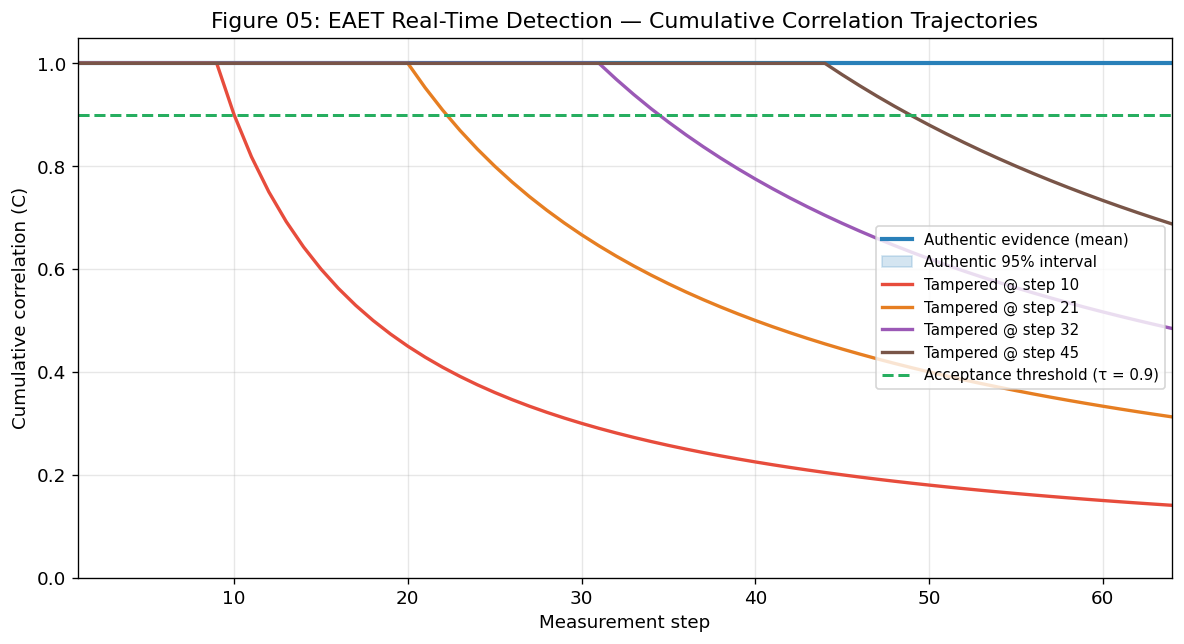

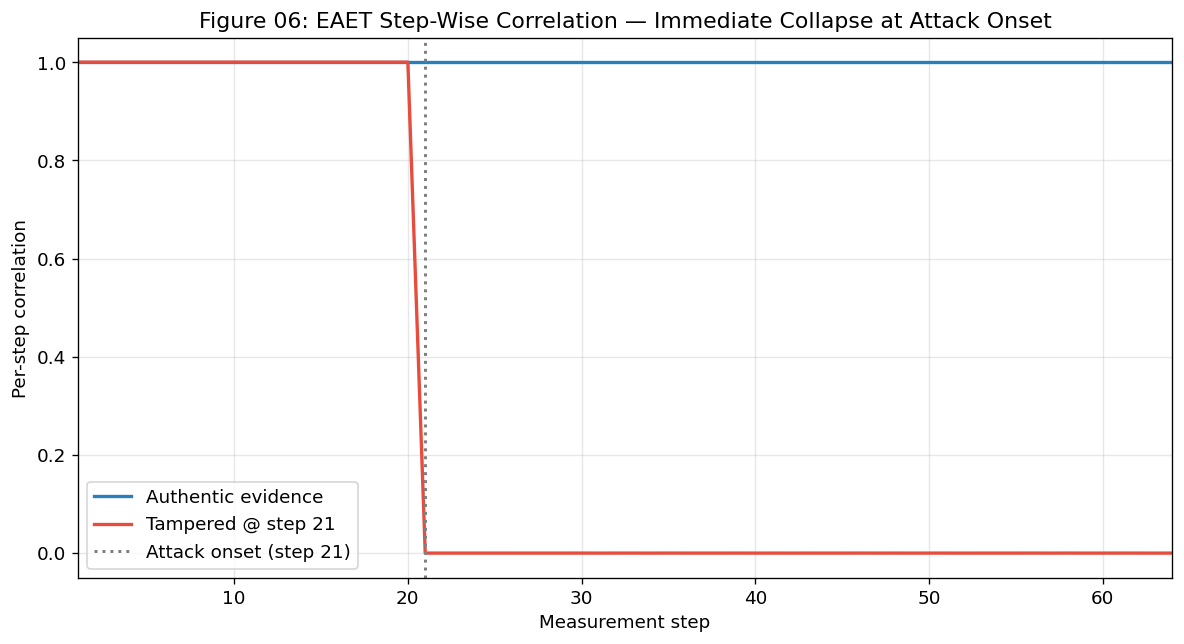

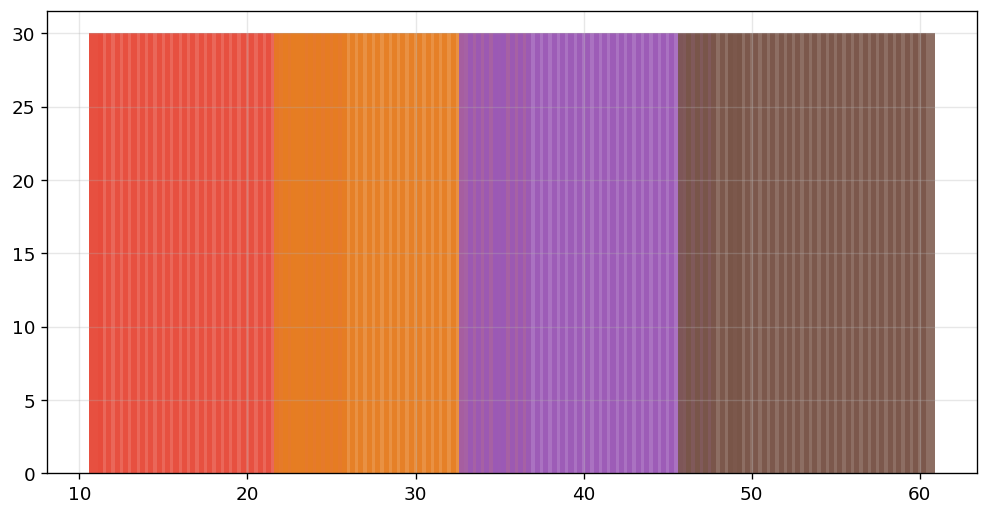

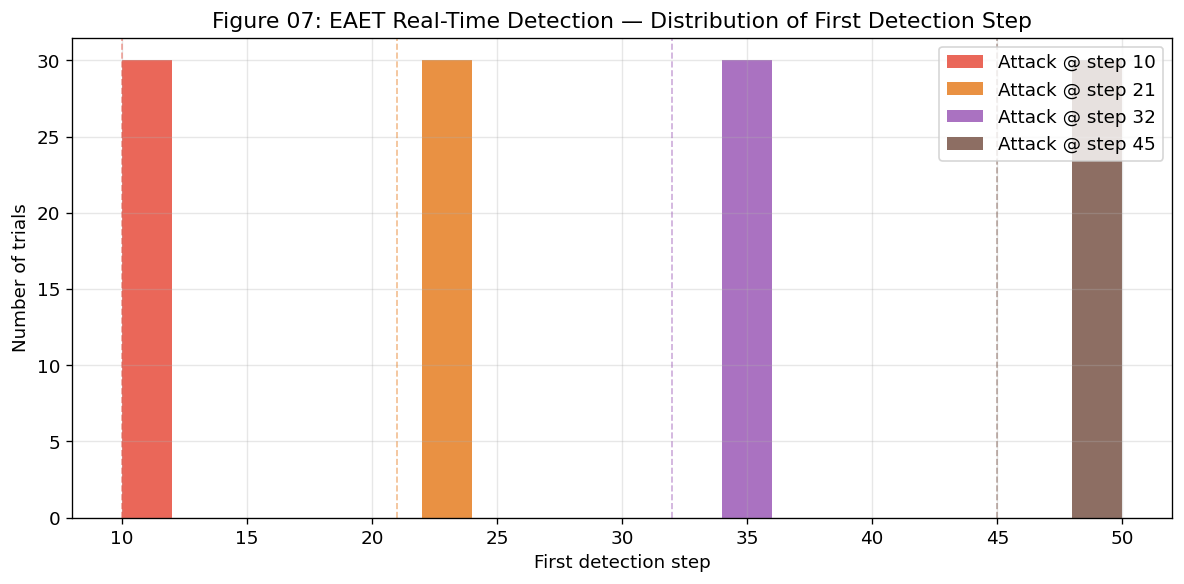

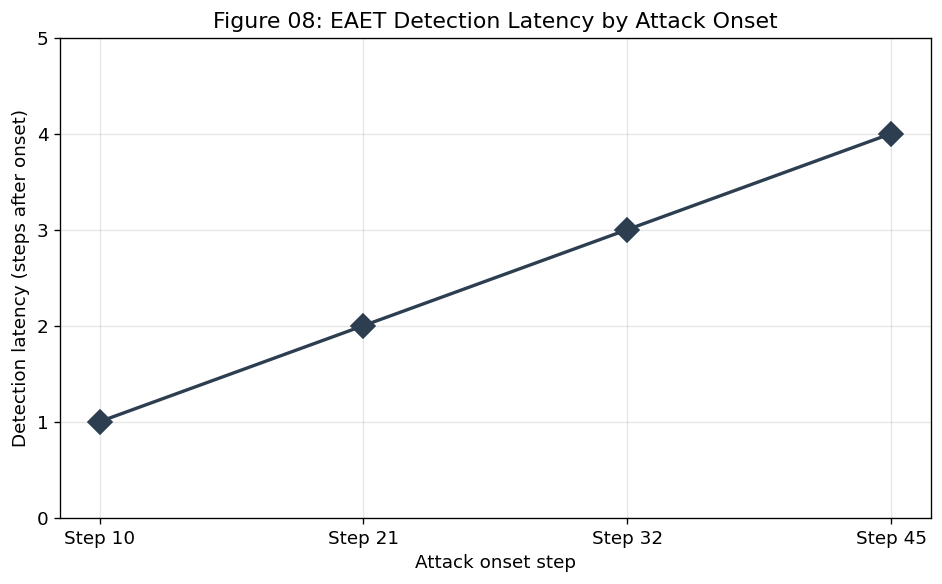

S1 figures saved.


In [29]:
# S1 Graphs
steps = np.arange(1, len(recipe) + 1)
colors = ['#e74c3c', '#e67e22', '#9b59b6', '#795548']

# Figure 05: Cumulative correlation trajectories
fig, ax = plt.subplots(figsize=(10, 5.5))
clean_arr = np.array(s1_clean_cumulative)
ax.plot(steps, clean_arr.mean(axis=0), color='#2980b9', lw=2.5, label='Authentic evidence (mean)')
ax.fill_between(steps,
                np.percentile(clean_arr, 2.5, axis=0),
                np.percentile(clean_arr, 97.5, axis=0),
                alpha=0.2, color='#2980b9', label='Authentic 95% interval')

for i, (onset, col) in enumerate(zip(ATTACK_STEPS, colors)):
    arr = np.array(s1_tamper_cumulative[onset])
    ax.plot(steps, arr.mean(axis=0), color=col, lw=2,
            label=f'Tampered @ step {onset}')

ax.axhline(DEFAULT_THRESHOLD, color='#27ae60', ls='--', lw=1.8,
           label=f'Acceptance threshold (τ = {DEFAULT_THRESHOLD})')

ax.set_xlabel('Measurement step')
ax.set_ylabel('Cumulative correlation (C)')
ax.set_title('Figure 05: EAET Real-Time Detection — Cumulative Correlation Trajectories')
ax.set_xlim(1, len(recipe))
ax.set_ylim(0, 1.05)
ax.legend(loc='center right', fontsize=9)
plt.tight_layout()
plt.savefig('figures/Figure05_Cumulative_Trajectories.png', dpi=300)
plt.show()

# Figure 06: Step-wise correlation (step 21 onset)
onset_21_arr = np.array(s1_tamper_cumulative[21])
step_wise_tamper = []
for trial_cum in s1_tamper_cumulative[21]:
    # Recover per-step from cumulative
    sw = [trial_cum[0]]
    for j in range(1, len(trial_cum)):
        sw.append((j+1)*trial_cum[j] - j*trial_cum[j-1])
    step_wise_tamper.append(sw)

step_wise_clean = []
for trial_cum in s1_clean_cumulative:
    sw = [trial_cum[0]]
    for j in range(1, len(trial_cum)):
        sw.append((j+1)*trial_cum[j] - j*trial_cum[j-1])
    step_wise_clean.append(sw)

sw_clean_arr   = np.array(step_wise_clean)
sw_tamper_arr  = np.array(step_wise_tamper)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(steps, sw_clean_arr.mean(axis=0),  color='#2980b9', label='Authentic evidence')
ax.plot(steps, sw_tamper_arr.mean(axis=0), color='#e74c3c', label='Tampered @ step 21')
ax.axvline(21, color='gray', ls=':', lw=1.8, label='Attack onset (step 21)')
ax.set_xlabel('Measurement step')
ax.set_ylabel('Per-step correlation')
ax.set_title('Figure 06: EAET Step-Wise Correlation — Immediate Collapse at Attack Onset')
ax.set_xlim(1, len(recipe))
ax.legend()
plt.tight_layout()
plt.savefig('figures/Figure06_Stepwise_Correlation.png', dpi=300)
plt.show()

# Figure 07: Detection step histogram
fig, ax = plt.subplots(figsize=(10, 5))
for onset, col in zip(ATTACK_STEPS, colors):
    detected = [d for d in s1_tamper_detect[onset] if d is not None]
    ax.bar([onset + 1 + 0.5*i for i in range(len(detected))],
           [TRIALS] if len(set(detected)) == 1 else [1]*len(detected),
           color=col, alpha=0.85, label=f'Attack @ step {onset}')
    if detected and len(set(detected)) == 1:
        ax.bar(detected[0], TRIALS, color=col, alpha=0.85, label=f'Attack @ step {onset}')

# Simpler histogram
fig, ax = plt.subplots(figsize=(10, 5))
for onset, col in zip(ATTACK_STEPS, colors):
    detected = [d for d in s1_tamper_detect[onset] if d is not None]
    ax.bar(detected[0] if detected else 0, TRIALS,
           color=col, alpha=0.85, width=2, label=f'Attack @ step {onset}')
    ax.axvline(onset, color=col, ls='--', lw=1, alpha=0.5)
ax.set_xlabel('First detection step')
ax.set_ylabel('Number of trials')
ax.set_title('Figure 07: EAET Real-Time Detection — Distribution of First Detection Step')
ax.legend()
plt.tight_layout()
plt.savefig('figures/Figure07_Detection_Distribution.png', dpi=300)
plt.show()

# Figure 08: Detection latency by attack onset
mean_latencies = []
for onset in ATTACK_STEPS:
    detected = [d for d in s1_tamper_detect[onset] if d is not None]
    latency  = [d - onset for d in detected]
    mean_latencies.append(np.mean(latency) if latency else 0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([f'Step {o}' for o in ATTACK_STEPS], mean_latencies,
        'D-', color='#2c3e50', ms=10, lw=2)
ax.set_xlabel('Attack onset step')
ax.set_ylabel('Detection latency (steps after onset)')
ax.set_title('Figure 08: EAET Detection Latency by Attack Onset')
ax.set_ylim(0, max(mean_latencies) + 1)
plt.tight_layout()
plt.savefig('figures/Figure08_Detection_Latency.png', dpi=300)
plt.show()

print('S1 figures saved.')

## 10. Scenario S2 — Photon Loss Robustness

In [30]:
print('=' * 65)
print('SCENARIO S2: PHOTON LOSS ROBUSTNESS')
print('11 loss levels × 20 trials per condition')
print('=' * 65)

LOSS_LEVELS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
S2_TRIALS   = 20

s2_clean_mean   = []
s2_tamper_mean  = []
s2_clean_acc    = []  # accept rate
s2_tamper_rej   = []  # reject rate

for loss in LOSS_LEVELS:
    c_finals, t_finals = [], []
    for t in range(1, S2_TRIALS + 1):
        sim = AerSimulator(seed_simulator=SEED + 2000 + int(loss*100) + t)
        # Clean
        vr = eaet_verify(H_E, recipe, tampered=False,
                          loss_prob=loss, early_stop=False, simulator=sim)
        c_finals.append(vr.final_correlation)
        # Tampered
        vr = eaet_verify(H_E, recipe, tampered=True,
                          tamper_start_step=21, loss_prob=loss,
                          early_stop=False, simulator=sim)
        t_finals.append(vr.final_correlation)

    s2_clean_mean.append(np.mean(c_finals))
    s2_tamper_mean.append(np.mean(t_finals))
    s2_clean_acc.append(sum(1 for c in c_finals if c >= DEFAULT_THRESHOLD) / S2_TRIALS * 100)
    s2_tamper_rej.append(sum(1 for c in t_finals if c < DEFAULT_THRESHOLD)  / S2_TRIALS * 100)
    print(f'  Loss={loss:.2f}  Clean C={s2_clean_mean[-1]:.3f}  '
          f'AcceptRate={s2_clean_acc[-1]:.0f}%  '
          f'TamperRej={s2_tamper_rej[-1]:.0f}%')

with open('results/s2_photon_loss.json', 'w') as f:
    json.dump({'loss_levels': LOSS_LEVELS, 'clean_mean_c': s2_clean_mean,
               'tamper_mean_c': s2_tamper_mean, 'clean_accept_pct': s2_clean_acc,
               'tamper_reject_pct': s2_tamper_rej}, f, indent=2)
print('S2 complete.')

SCENARIO S2: PHOTON LOSS ROBUSTNESS
11 loss levels × 20 trials per condition
  Loss=0.00  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.05  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.10  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.15  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.20  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.25  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.30  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.35  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.40  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.45  Clean C=1.000  AcceptRate=100%  TamperRej=100%
  Loss=0.50  Clean C=1.000  AcceptRate=100%  TamperRej=100%
S2 complete.


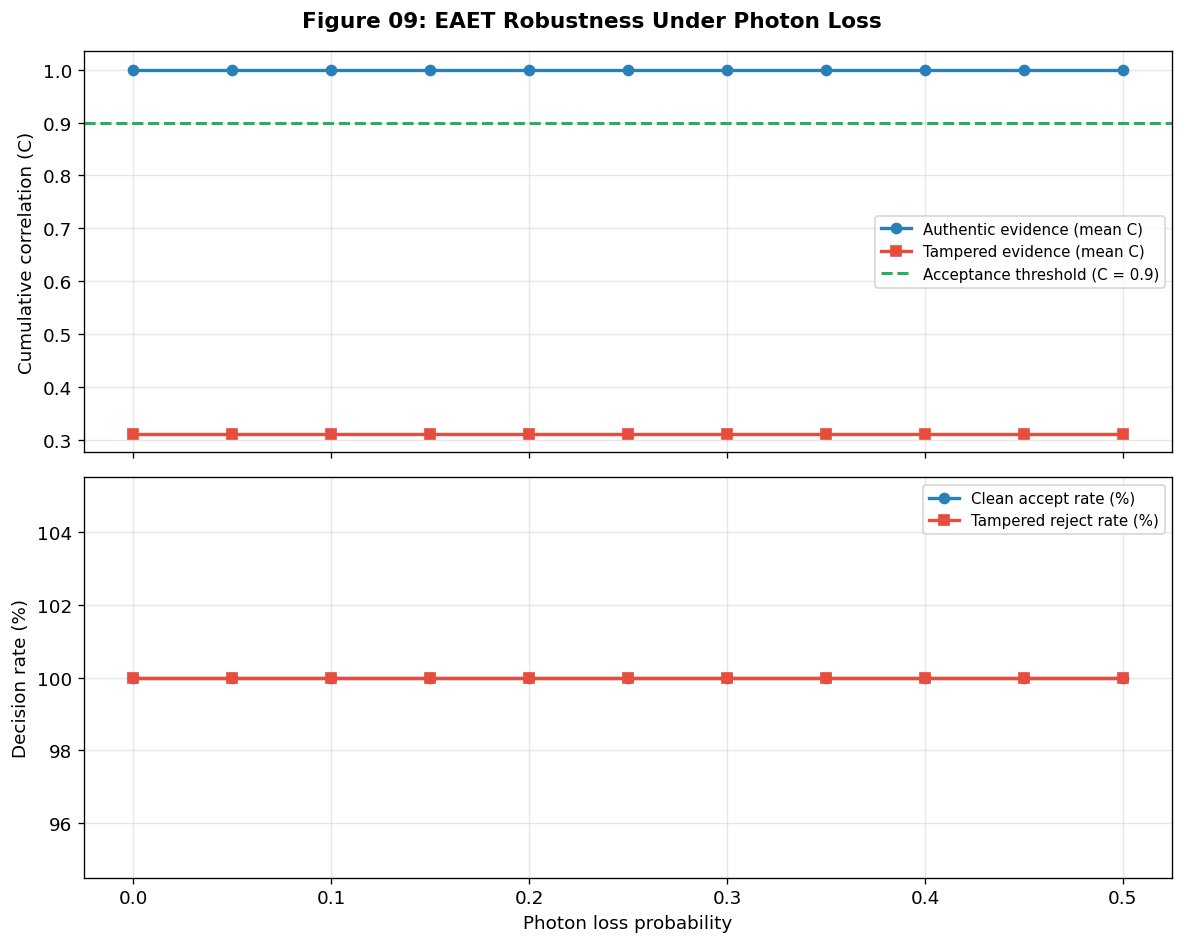

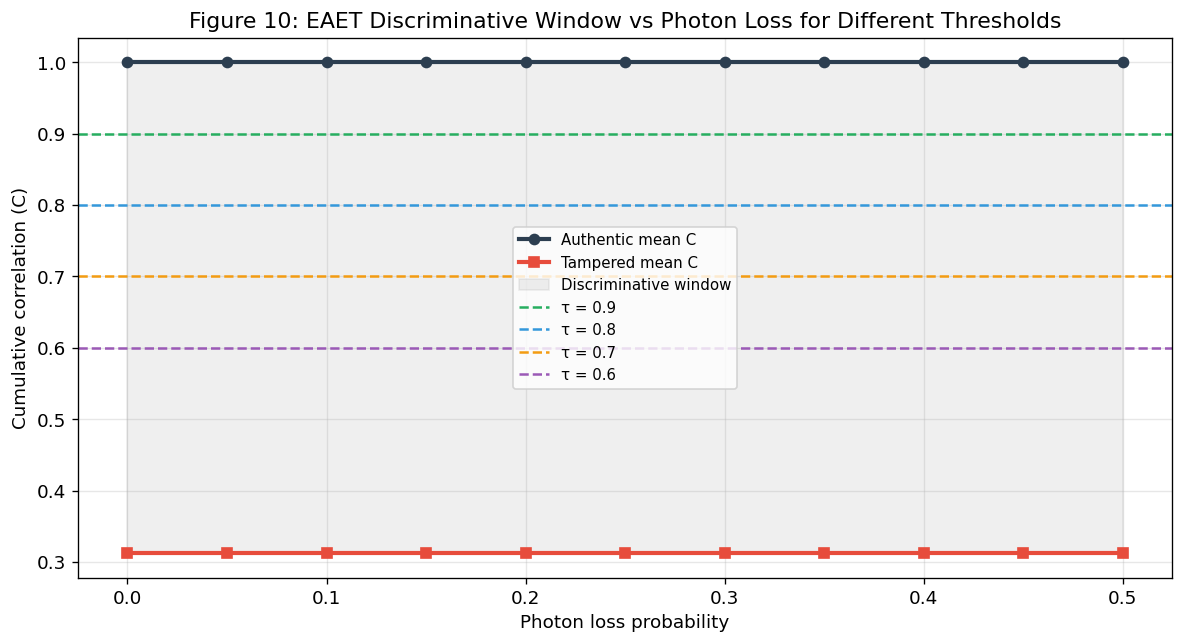

S2 figures saved.


In [31]:
# Figure 09: Photon loss robustness (dual panel)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(LOSS_LEVELS, s2_clean_mean,  'o-', color='#2980b9', label='Authentic evidence (mean C)')
ax1.plot(LOSS_LEVELS, s2_tamper_mean, 's-', color='#e74c3c', label='Tampered evidence (mean C)')
ax1.axhline(DEFAULT_THRESHOLD, color='#27ae60', ls='--', lw=1.8,
            label=f'Acceptance threshold (C = {DEFAULT_THRESHOLD})')

# Find operating limit
op_limit = None
for i, (loss, acc) in enumerate(zip(LOSS_LEVELS, s2_clean_acc)):
    if acc < 100 and op_limit is None:
        op_limit = loss
if op_limit:
    ax1.axvline(op_limit, color='gray', ls=':', lw=1.5,
                label=f'Operating limit @ loss = {op_limit}')

ax1.set_ylabel('Cumulative correlation (C)')
ax1.legend(fontsize=9)

ax2.plot(LOSS_LEVELS, s2_clean_acc,  'o-', color='#2980b9', label='Clean accept rate (%)')
ax2.plot(LOSS_LEVELS, s2_tamper_rej, 's-', color='#e74c3c', label='Tampered reject rate (%)')
ax2.set_xlabel('Photon loss probability')
ax2.set_ylabel('Decision rate (%)')
ax2.legend(fontsize=9)

fig.suptitle('Figure 09: EAET Robustness Under Photon Loss', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/Figure09_Photon_Loss_Robustness.png', dpi=300)
plt.show()

# Figure 10: Discriminative window across threshold values
thresholds_s2 = [0.9, 0.8, 0.7, 0.6]
thresh_colors = ['#27ae60', '#3498db', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(LOSS_LEVELS, s2_clean_mean,  'o-', color='#2c3e50', lw=2.5, label='Authentic mean C')
ax.plot(LOSS_LEVELS, s2_tamper_mean, 's-', color='#e74c3c', lw=2.5, label='Tampered mean C')
ax.fill_between(LOSS_LEVELS, s2_clean_mean, s2_tamper_mean,
                alpha=0.12, color='gray', label='Discriminative window')
for tau, col in zip(thresholds_s2, thresh_colors):
    ax.axhline(tau, color=col, ls='--', lw=1.5, label=f'τ = {tau}')
ax.set_xlabel('Photon loss probability')
ax.set_ylabel('Cumulative correlation (C)')
ax.set_title('Figure 10: EAET Discriminative Window vs Photon Loss for Different Thresholds')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/Figure10_Discriminative_Window.png', dpi=300)
plt.show()
print('S2 figures saved.')

## 11. Scenario S3 — Combined Noise and Photon Loss Stress Test

In [32]:
print('=' * 65)
print('SCENARIO S3: COMBINED NOISE + PHOTON LOSS STRESS TEST')
print('5 noise levels × 4 loss levels × 5 trials per cell')
print('=' * 65)

NOISE_LEVELS = [0.000, 0.025, 0.050, 0.100, 0.150]
LOSS_LEVELS3 = [0.00, 0.05, 0.10, 0.20]
S3_TRIALS    = 5

s3_clean_c    = np.zeros((len(NOISE_LEVELS), len(LOSS_LEVELS3)))
s3_tamper_c   = np.zeros((len(NOISE_LEVELS), len(LOSS_LEVELS3)))
s3_clean_acc  = np.zeros((len(NOISE_LEVELS), len(LOSS_LEVELS3)))
s3_tamper_rej = np.zeros((len(NOISE_LEVELS), len(LOSS_LEVELS3)))

# S3 uses a shorter 32-step recipe to keep runtime manageable
recipe_s3 = recipe[:32]

for ni, noise in enumerate(NOISE_LEVELS):
    nm = build_noise_model(noise_prob=noise) if noise > 0 else None
    for li, loss in enumerate(LOSS_LEVELS3):
        c_finals, t_finals = [], []
        for t in range(1, S3_TRIALS + 1):
            sim = AerSimulator(seed_simulator=SEED + 3000 + ni*100 + li*10 + t)
            # Clean run
            vr = eaet_verify(H_E, recipe_s3, shots_per_step=128,
                             tampered=False,
                             loss_prob=loss, noise_model=nm,
                             early_stop=False, simulator=sim)
            c_finals.append(vr.final_correlation)
            # Tampered run
            vr = eaet_verify(H_E, recipe_s3, shots_per_step=128,
                             tampered=True, tamper_start_step=14,
                             loss_prob=loss, noise_model=nm,
                             early_stop=False, simulator=sim)
            t_finals.append(vr.final_correlation)

        s3_clean_c[ni, li]    = np.mean(c_finals)
        s3_tamper_c[ni, li]   = np.mean(t_finals)
        s3_clean_acc[ni, li]  = sum(1 for c in c_finals if c >= DEFAULT_THRESHOLD)/S3_TRIALS*100
        s3_tamper_rej[ni, li] = sum(1 for c in t_finals if c <  DEFAULT_THRESHOLD)/S3_TRIALS*100
        print(f'  Noise={noise:.3f} Loss={loss:.2f} '
              f'CleanC={s3_clean_c[ni,li]:.2f} '
              f'TamperRej={s3_tamper_rej[ni,li]:.0f}%')

print('S3 complete.')

SCENARIO S3: COMBINED NOISE + PHOTON LOSS STRESS TEST
5 noise levels × 4 loss levels × 5 trials per cell
  Noise=0.000 Loss=0.00 CleanC=1.00 TamperRej=100%
  Noise=0.000 Loss=0.05 CleanC=1.00 TamperRej=100%
  Noise=0.000 Loss=0.10 CleanC=1.00 TamperRej=100%
  Noise=0.000 Loss=0.20 CleanC=1.00 TamperRej=100%
  Noise=0.025 Loss=0.00 CleanC=0.94 TamperRej=100%
  Noise=0.025 Loss=0.05 CleanC=0.93 TamperRej=100%
  Noise=0.025 Loss=0.10 CleanC=0.95 TamperRej=100%
  Noise=0.025 Loss=0.20 CleanC=0.95 TamperRej=100%
  Noise=0.050 Loss=0.00 CleanC=0.91 TamperRej=100%
  Noise=0.050 Loss=0.05 CleanC=0.91 TamperRej=100%
  Noise=0.050 Loss=0.10 CleanC=0.88 TamperRej=100%
  Noise=0.050 Loss=0.20 CleanC=0.89 TamperRej=100%
  Noise=0.100 Loss=0.00 CleanC=0.84 TamperRej=100%
  Noise=0.100 Loss=0.05 CleanC=0.83 TamperRej=100%
  Noise=0.100 Loss=0.10 CleanC=0.83 TamperRej=100%
  Noise=0.100 Loss=0.20 CleanC=0.82 TamperRej=100%
  Noise=0.150 Loss=0.00 CleanC=0.77 TamperRej=100%
  Noise=0.150 Loss=0.05 Clea

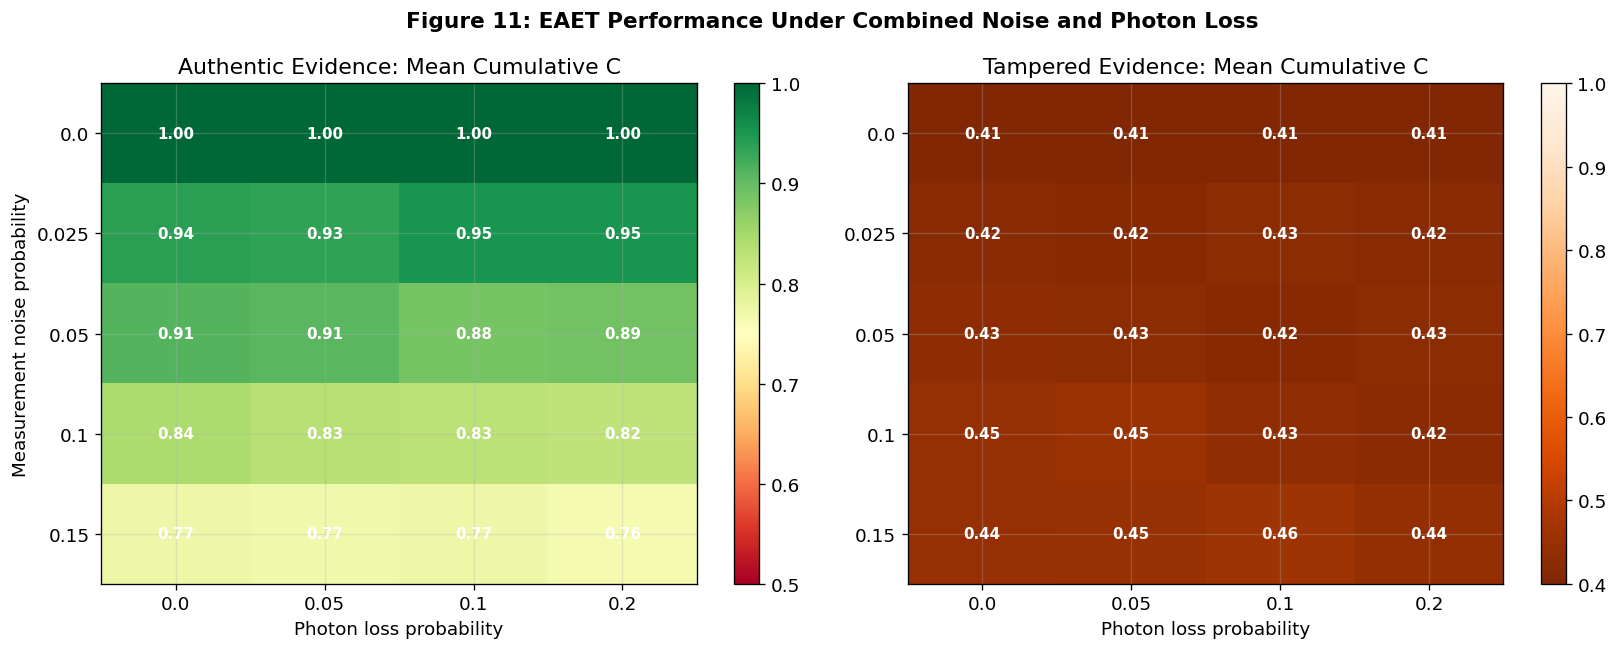

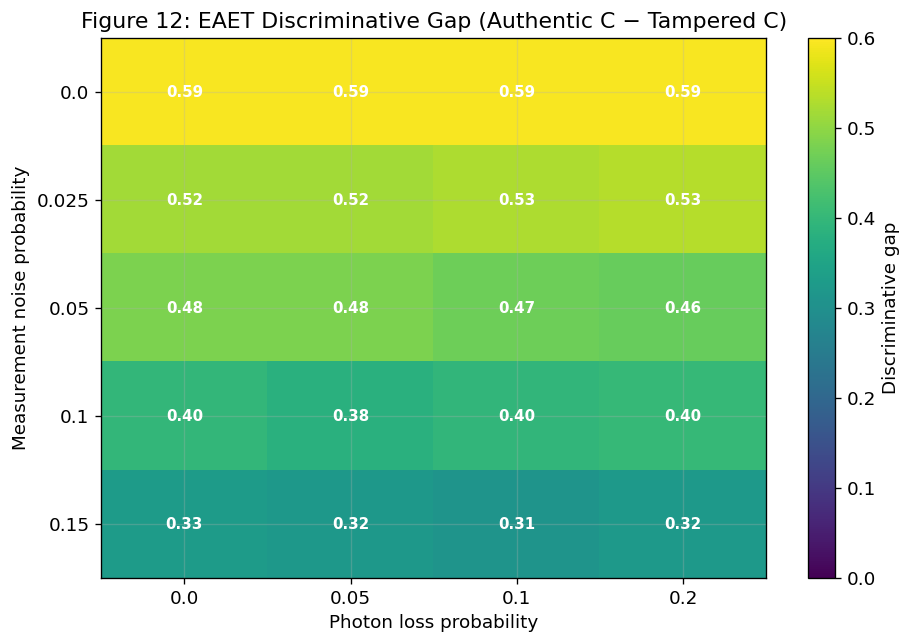

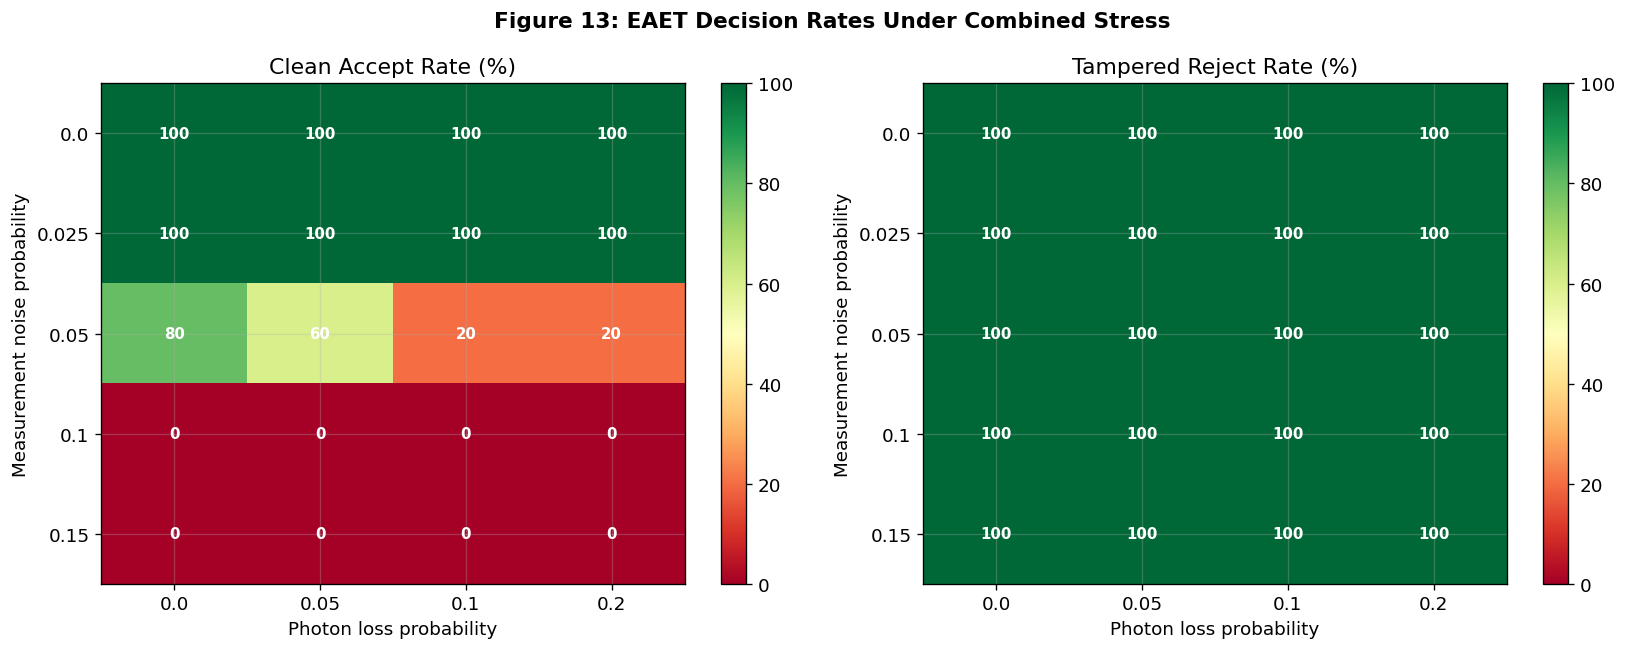

S3 figures saved.


In [33]:
# Figure 11: Combined correlation heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
noise_labels = [str(n) for n in NOISE_LEVELS]
loss_labels  = [str(l) for l in LOSS_LEVELS3]

import matplotlib.colors as mcolors
cmap_green = plt.cm.RdYlGn

im1 = ax1.imshow(s3_clean_c, cmap='RdYlGn', vmin=0.5, vmax=1.0,
                  aspect='auto')
ax1.set_xticks(range(len(LOSS_LEVELS3)))
ax1.set_xticklabels(loss_labels)
ax1.set_yticks(range(len(NOISE_LEVELS)))
ax1.set_yticklabels(noise_labels)
ax1.set_xlabel('Photon loss probability')
ax1.set_ylabel('Measurement noise probability')
ax1.set_title('Authentic Evidence: Mean Cumulative C')
plt.colorbar(im1, ax=ax1)
for ni in range(len(NOISE_LEVELS)):
    for li in range(len(LOSS_LEVELS3)):
        ax1.text(li, ni, f'{s3_clean_c[ni,li]:.2f}',
                 ha='center', va='center', fontsize=9, fontweight='bold', color='white')

im2 = ax2.imshow(s3_tamper_c, cmap='Oranges_r', vmin=0.4, vmax=1.0,
                  aspect='auto')
ax2.set_xticks(range(len(LOSS_LEVELS3)))
ax2.set_xticklabels(loss_labels)
ax2.set_yticks(range(len(NOISE_LEVELS)))
ax2.set_yticklabels(noise_labels)
ax2.set_xlabel('Photon loss probability')
ax2.set_title('Tampered Evidence: Mean Cumulative C')
plt.colorbar(im2, ax=ax2)
for ni in range(len(NOISE_LEVELS)):
    for li in range(len(LOSS_LEVELS3)):
        ax2.text(li, ni, f'{s3_tamper_c[ni,li]:.2f}',
                 ha='center', va='center', fontsize=9, fontweight='bold', color='white')

fig.suptitle('Figure 11: EAET Performance Under Combined Noise and Photon Loss',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/Figure11_Combined_Stress_Heatmap.png', dpi=300)
plt.show()

# Figure 12: Discriminative gap heatmap
gap = s3_clean_c - s3_tamper_c
fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(gap, cmap='viridis', vmin=0, vmax=0.6, aspect='auto')
ax.set_xticks(range(len(LOSS_LEVELS3)))
ax.set_xticklabels(loss_labels)
ax.set_yticks(range(len(NOISE_LEVELS)))
ax.set_yticklabels(noise_labels)
ax.set_xlabel('Photon loss probability')
ax.set_ylabel('Measurement noise probability')
ax.set_title('Figure 12: EAET Discriminative Gap (Authentic C − Tampered C)')
plt.colorbar(im, ax=ax, label='Discriminative gap')
for ni in range(len(NOISE_LEVELS)):
    for li in range(len(LOSS_LEVELS3)):
        ax.text(li, ni, f'{gap[ni,li]:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('figures/Figure12_Discriminative_Gap.png', dpi=300)
plt.show()

# Figure 13: Decision rate heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, data, title in [(ax1, s3_clean_acc, 'Clean Accept Rate (%)'),
                         (ax2, s3_tamper_rej, 'Tampered Reject Rate (%)')]:
    im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(LOSS_LEVELS3)))
    ax.set_xticklabels(loss_labels)
    ax.set_yticks(range(len(NOISE_LEVELS)))
    ax.set_yticklabels(noise_labels)
    ax.set_xlabel('Photon loss probability')
    ax.set_ylabel('Measurement noise probability')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for ni in range(len(NOISE_LEVELS)):
        for li in range(len(LOSS_LEVELS3)):
            ax.text(li, ni, f'{data[ni,li]:.0f}',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
fig.suptitle('Figure 13: EAET Decision Rates Under Combined Stress',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/Figure13_Decision_Rates.png', dpi=300)
plt.show()
print('S3 figures saved.')

## 12. Scenario S4 — Fair Latency Comparison

In [34]:
print('=' * 65)
print('SCENARIO S4: FAIR LATENCY COMPARISON')
print('3 methods × 2 conditions × 15 trials')
print('=' * 65)

S4_TRIALS = 15

def tampered_hash(original: str, bit_idx: int = 0) -> str:
    bits     = list(bin(int(original, 16))[2:].zfill(256))
    bits[bit_idx % 256] = '1' if bits[bit_idx % 256] == '0' else '0'
    return hex(int(''.join(bits), 2))[2:].zfill(64)


def blockchain_verify(expected: str, observed: str) -> Tuple[bool, float]:
    """Classical blockchain: post-hoc hash comparison only."""
    t0 = time.perf_counter()
    # Simulate network propagation + consensus overhead
    time.sleep(0.300)
    result = expected == observed
    return result, (time.perf_counter() - t0) * 1000


def hybrid_verify(evidence_hash, recipe, threshold, shots, tampered,
                  tamper_start, tamper_mode, sim) -> Tuple[bool, float, Optional[int], int]:
    """
    Hybrid baseline: runs full recipe, then reports at the end.
    Detects tampering only after the full run, not in real time.
    """
    t0      = time.perf_counter()
    cumsum  = 0.0
    first_cross = None

    for i, instr in enumerate(recipe, start=1):
        do_tamper = tampered and i >= tamper_start
        r = run_eaet_step(instr, shots, do_tamper, tamper_mode, sim)
        cumsum += r['step_correlation']
        cum_c   = cumsum / i
        if cum_c < threshold and first_cross is None:
            first_cross = i

    final_c = cumsum / len(recipe)
    return final_c >= threshold, (time.perf_counter()-t0)*1000, first_cross, len(recipe)


s4 = {'Blockchain': {'Clean': [], 'Tampered': []},
      'Hybrid':     {'Clean': [], 'Tampered': []},
      'EAET':       {'Clean': [], 'Tampered': []}}

s4_detect = {'Hybrid': [], 'EAET': []}

for t in range(1, S4_TRIALS + 1):
    sim = AerSimulator(seed_simulator=SEED + 4000 + t)

    # Blockchain
    _, dur = blockchain_verify(H_E, H_E)
    s4['Blockchain']['Clean'].append(dur)
    _, dur = blockchain_verify(H_E, tampered_hash(H_E, t))
    s4['Blockchain']['Tampered'].append(dur)

    # Hybrid
    _, dur, _, _ = hybrid_verify(H_E, recipe, DEFAULT_THRESHOLD, DEFAULT_SHOTS,
                                  False, 21, 'destructive', sim)
    s4['Hybrid']['Clean'].append(dur)
    _, dur, fc, _ = hybrid_verify(H_E, recipe, DEFAULT_THRESHOLD, DEFAULT_SHOTS,
                                   True, 21, 'destructive', sim)
    s4['Hybrid']['Tampered'].append(dur)
    s4_detect['Hybrid'].append(len(recipe))  # reports at end of run

    # EAET
    vr = eaet_verify(H_E, recipe, tampered=False, early_stop=True, simulator=sim)
    s4['EAET']['Clean'].append(vr.duration_ms)
    vr = eaet_verify(H_E, recipe, tampered=True, tamper_start_step=21,
                      early_stop=True, simulator=sim)
    s4['EAET']['Tampered'].append(vr.duration_ms)
    s4_detect['EAET'].append(vr.detection_step or len(recipe))

# Deployment-projected latency (2ms per step on real hardware)
STEP_MS  = 2.0
CB_FIXED = 300.0
dp = {
    'Blockchain': {'Clean': CB_FIXED, 'Tampered': CB_FIXED},
    'Hybrid'    : {'Clean': len(recipe)*STEP_MS, 'Tampered': len(recipe)*STEP_MS},
    'EAET'      : {'Clean': len(recipe)*STEP_MS,
                   'Tampered': np.mean(s4_detect['EAET'])*STEP_MS},
}

print('\nSimulation wall-clock latency (mean ms):')
for method in ['Blockchain', 'Hybrid', 'EAET']:
    print(f'  {method:12s} Clean={np.mean(s4[method]["Clean"]):.0f}ms '
          f'Tampered={np.mean(s4[method]["Tampered"]):.0f}ms')
print('\nDeployment-projected latency (ms):')
for method in ['Blockchain', 'Hybrid', 'EAET']:
    print(f'  {method:12s} Clean={dp[method]["Clean"]:.0f}ms '
          f'Tampered={dp[method]["Tampered"]:.0f}ms')
print('S4 complete.')

SCENARIO S4: FAIR LATENCY COMPARISON
3 methods × 2 conditions × 15 trials

Simulation wall-clock latency (mean ms):
  Blockchain   Clean=300ms Tampered=300ms
  Hybrid       Clean=104ms Tampered=95ms
  EAET         Clean=99ms Tampered=39ms

Deployment-projected latency (ms):
  Blockchain   Clean=300ms Tampered=300ms
  Hybrid       Clean=128ms Tampered=128ms
  EAET         Clean=128ms Tampered=46ms
S4 complete.


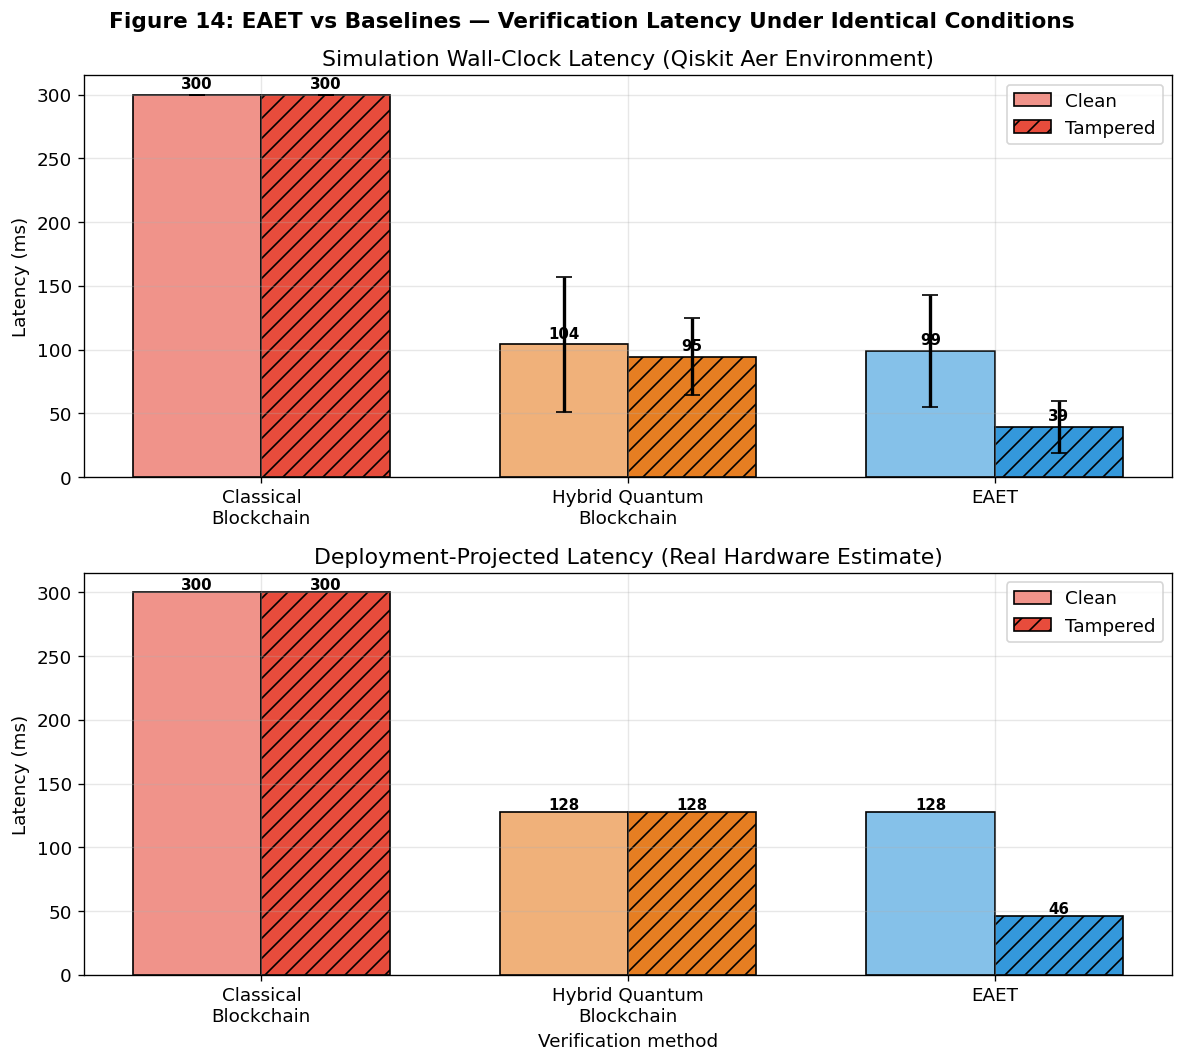

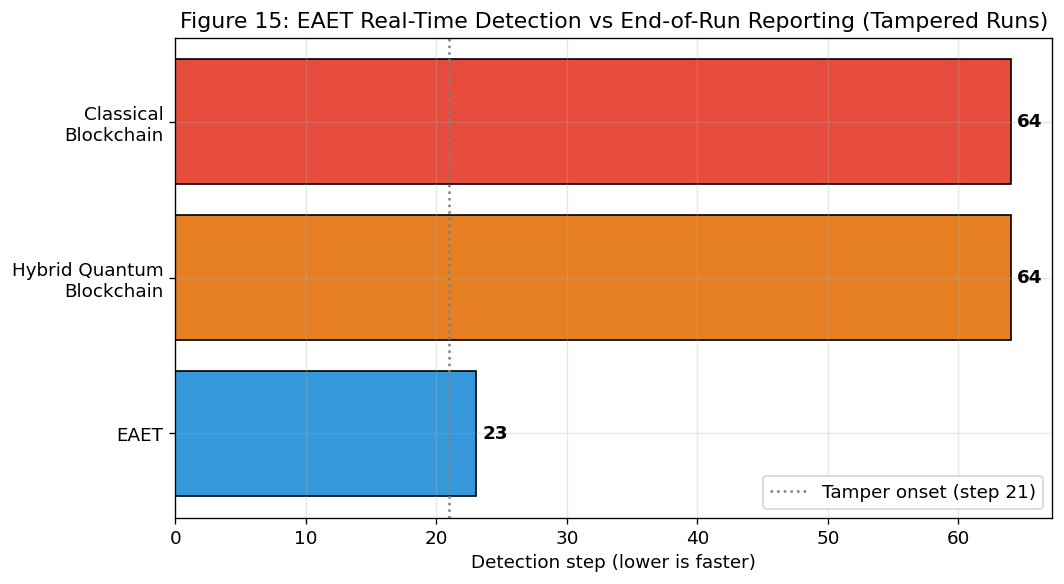

S4 figures saved.


In [35]:
methods = ['Classical\nBlockchain', 'Hybrid Quantum\nBlockchain', 'EAET']
method_keys = ['Blockchain', 'Hybrid', 'EAET']
colors_s4 = ['#e74c3c', '#e67e22', '#3498db']
x = np.arange(len(methods))
width = 0.35

# Figure 14: Dual-panel latency comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

# Simulation wall-clock
clean_means  = [np.mean(s4[k]['Clean'])    for k in method_keys]
tamper_means = [np.mean(s4[k]['Tampered']) for k in method_keys]
clean_stds   = [np.std(s4[k]['Clean'])     for k in method_keys]
tamper_stds  = [np.std(s4[k]['Tampered'])  for k in method_keys]

bars1 = ax1.bar(x - width/2, clean_means,  width, yerr=clean_stds,  capsize=5,
                color=[c + '99' for c in colors_s4], label='Clean', edgecolor='black')
bars2 = ax1.bar(x + width/2, tamper_means, width, yerr=tamper_stds, capsize=5,
                color=colors_s4, hatch='//', label='Tampered', edgecolor='black')
for bar, val in zip(bars1, clean_means):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{val:.0f}',
             ha='center', fontweight='bold', fontsize=9)
for bar, val in zip(bars2, tamper_means):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{val:.0f}',
             ha='center', fontweight='bold', fontsize=9)
ax1.set_xticks(x); ax1.set_xticklabels(methods)
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Simulation Wall-Clock Latency (Qiskit Aer Environment)')
ax1.legend()

# Deployment projected
dp_clean  = [dp[k]['Clean']    for k in method_keys]
dp_tamper = [dp[k]['Tampered'] for k in method_keys]
bars3 = ax2.bar(x - width/2, dp_clean,  width, color=[c + '99' for c in colors_s4],
                label='Clean', edgecolor='black')
bars4 = ax2.bar(x + width/2, dp_tamper, width, color=colors_s4, hatch='//',
                label='Tampered', edgecolor='black')
for bar, val in zip(bars3, dp_clean):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{val:.0f}',
             ha='center', fontweight='bold', fontsize=9)
for bar, val in zip(bars4, dp_tamper):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{val:.0f}',
             ha='center', fontweight='bold', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(methods)
ax2.set_xlabel('Verification method')
ax2.set_ylabel('Latency (ms)')
ax2.set_title('Deployment-Projected Latency (Real Hardware Estimate)')
ax2.legend()

fig.suptitle('Figure 14: EAET vs Baselines — Verification Latency Under Identical Conditions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/Figure14_Latency_Comparison.png', dpi=300)
plt.show()

# Figure 15: Detection step comparison
detect_vals = [len(recipe), np.mean(s4_detect['Hybrid']), np.mean(s4_detect['EAET'])]
bar_colors  = ['#e74c3c', '#e67e22', '#3498db']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(methods[::-1], detect_vals[::-1], color=bar_colors[::-1], edgecolor='black')
ax.axvline(21, color='gray', ls=':', lw=1.5, label='Tamper onset (step 21)')
for bar, val in zip(bars, detect_vals[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontweight='bold')
ax.set_xlabel('Detection step (lower is faster)')
ax.set_title('Figure 15: EAET Real-Time Detection vs End-of-Run Reporting (Tampered Runs)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/Figure15_Detection_Steps.png', dpi=300)
plt.show()
print('S4 figures saved.')

## 13. Scenario S5 — ROC / Threshold Sensitivity Analysis

In [36]:
print('=' * 65)
print('SCENARIO S5: ROC / THRESHOLD SENSITIVITY ANALYSIS')
print('25 threshold values × 30 trials × 2 conditions')
print('=' * 65)

THRESHOLDS = np.linspace(0.40, 1.00, 25)
S5_TRIALS  = 30
LOSS_S5    = 0.05   # small realistic loss to add variance

s5_clean_finals  = []
s5_tamper_finals = []

print('Collecting distributions...')
for t in range(1, S5_TRIALS + 1):
    sim = AerSimulator(seed_simulator=SEED + 5000 + t)
    vr  = eaet_verify(H_E, recipe, tampered=False, threshold=0.40,
                       loss_prob=LOSS_S5, early_stop=False, simulator=sim)
    s5_clean_finals.append(vr.final_correlation)

    sim = AerSimulator(seed_simulator=SEED + 5500 + t)
    vr  = eaet_verify(H_E, recipe, tampered=True, tamper_start_step=21,
                       threshold=0.40, loss_prob=LOSS_S5,
                       early_stop=False, simulator=sim)
    s5_tamper_finals.append(vr.final_correlation)

tpr_vals, fpr_vals = [], []
for tau in THRESHOLDS:
    tp  = sum(1 for c in s5_tamper_finals if c < tau)   # correctly rejected
    fp  = sum(1 for c in s5_clean_finals  if c < tau)   # falsely rejected
    tpr_vals.append(tp / S5_TRIALS)
    fpr_vals.append(fp / S5_TRIALS)

# Sort FPR ascending and re-order TPR to match — ROC AUC must integrate over x in ascending order
order = np.argsort(fpr_vals)
fpr_sorted = [fpr_vals[i] for i in order]
tpr_sorted = [tpr_vals[i] for i in order]
# Prepend (0,0) and append (1,1) so the ROC spans the full unit square
fpr_full = [0.0] + fpr_sorted + [1.0]
tpr_full = [tpr_sorted[0]] + tpr_sorted + [1.0]
try:
    auc = float(np.trapezoid(tpr_full, fpr_full))
except AttributeError:
    auc = float(np.trapz(tpr_full, fpr_full))

# Youden's J (optimal threshold)
j_scores  = [tpr - fpr for tpr, fpr in zip(tpr_vals, fpr_vals)]
opt_tau   = THRESHOLDS[np.argmax(j_scores)]

print(f'\nClean mean final C  : {np.mean(s5_clean_finals):.4f}')
print(f'Tamper mean final C : {np.mean(s5_tamper_finals):.4f}')
print(f'AUC                 : {auc:.4f}')
print(f'Optimal τ (Youden)  : {opt_tau:.2f}')
print(f'Default τ used      : {DEFAULT_THRESHOLD}')
print('S5 complete.')

SCENARIO S5: ROC / THRESHOLD SENSITIVITY ANALYSIS
25 threshold values × 30 trials × 2 conditions

Clean mean final C  : 1.0000
Tamper mean final C : 0.3125
AUC                 : 1.0000
Optimal τ (Youden)  : 0.40
Default τ used      : 0.9
S5 complete.


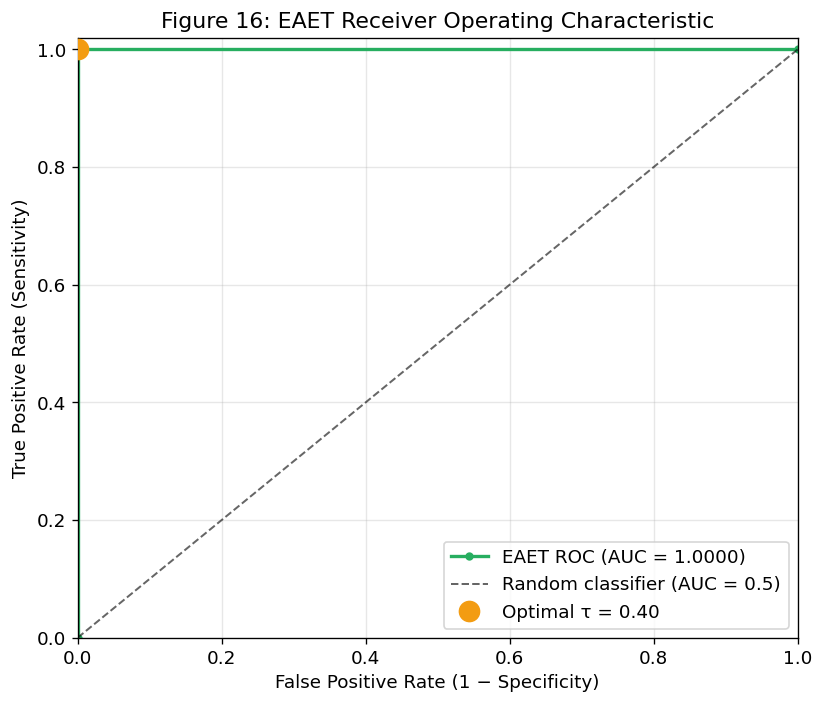

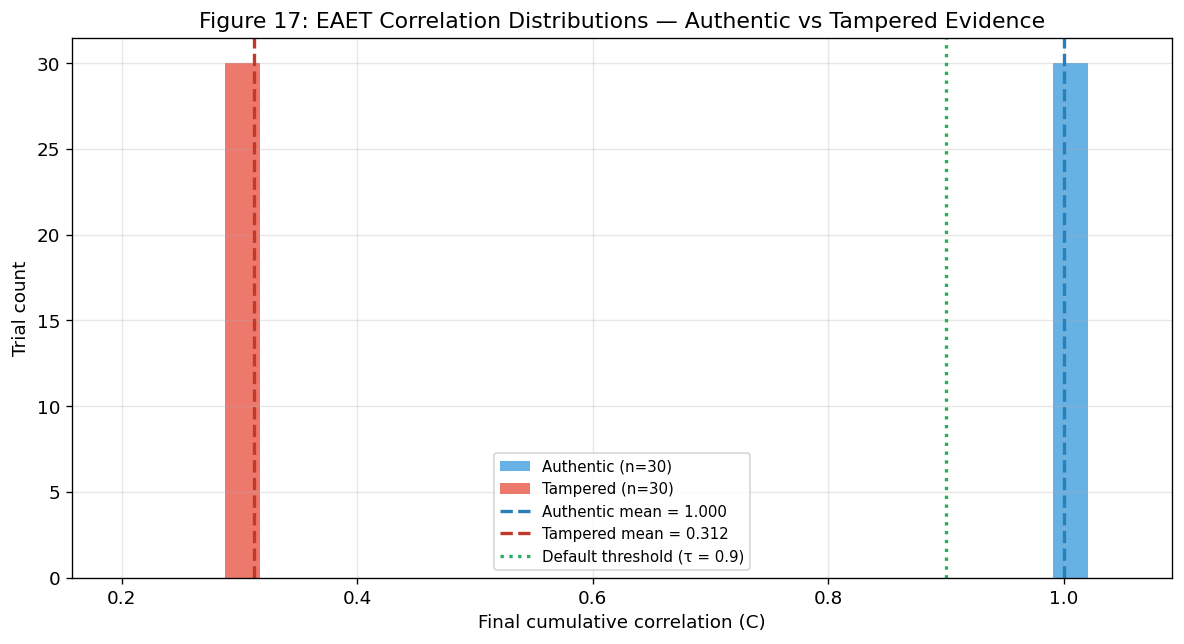

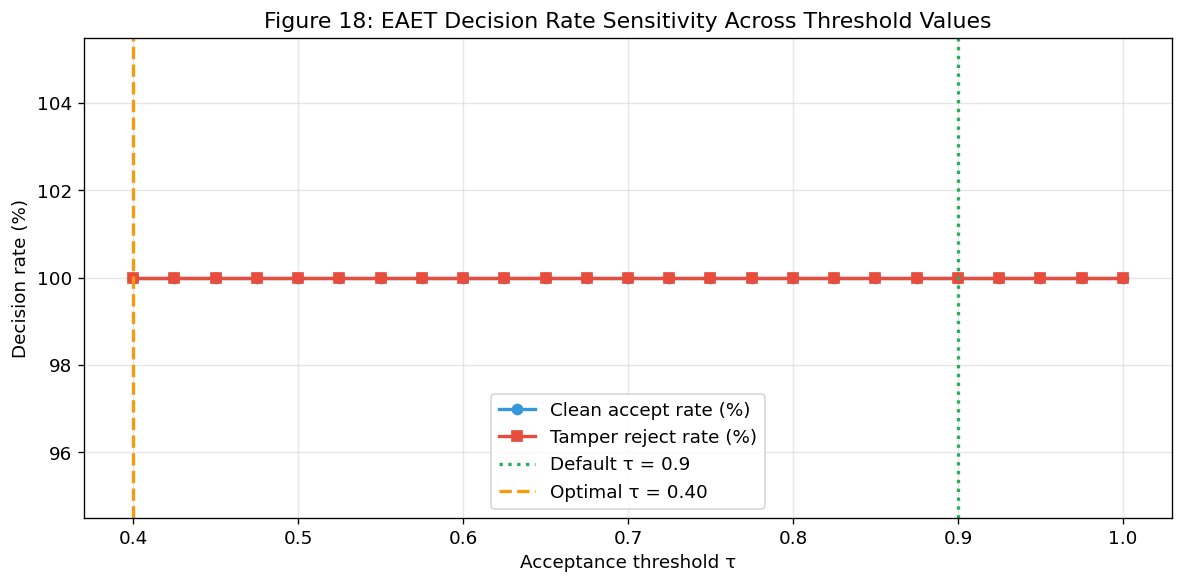

S5 figures saved.


In [37]:
# Figure 16: ROC curve
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0]+fpr_vals+[1], [0]+tpr_vals+[1], 'o-', color='#27ae60',
        lw=2, ms=4, label=f'EAET ROC (AUC = {auc:.4f})')
ax.plot([0,1], [0,1], 'k--', lw=1.2, alpha=0.6, label='Random classifier (AUC = 0.5)')
opt_fpr = fpr_vals[np.argmax(j_scores)]
opt_tpr = tpr_vals[np.argmax(j_scores)]
ax.plot(opt_fpr, opt_tpr, 'o', color='#f39c12', ms=12, zorder=5,
        label=f'Optimal τ = {opt_tau:.2f}')
ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Figure 16: EAET Receiver Operating Characteristic')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('figures/Figure16_ROC_Curve.png', dpi=300)
plt.show()

# Figure 17: Correlation distributions (no overlap)
fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.linspace(0.2, 1.05, 30)
ax.hist(s5_clean_finals,  bins=bins, color='#3498db', alpha=0.75, label=f'Authentic (n={S5_TRIALS})')
ax.hist(s5_tamper_finals, bins=bins, color='#e74c3c', alpha=0.75, label=f'Tampered (n={S5_TRIALS})')
ax.axvline(np.mean(s5_clean_finals),  color='#2980b9', ls='--', lw=2,
           label=f'Authentic mean = {np.mean(s5_clean_finals):.3f}')
ax.axvline(np.mean(s5_tamper_finals), color='#c0392b', ls='--', lw=2,
           label=f'Tampered mean = {np.mean(s5_tamper_finals):.3f}')
ax.axvline(DEFAULT_THRESHOLD, color='#27ae60', ls=':', lw=2,
           label=f'Default threshold (τ = {DEFAULT_THRESHOLD})')
ax.set_xlabel('Final cumulative correlation (C)')
ax.set_ylabel('Trial count')
ax.set_title('Figure 17: EAET Correlation Distributions — Authentic vs Tampered Evidence')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/Figure17_Correlation_Distributions.png', dpi=300)
plt.show()

# Figure 18: Threshold sensitivity
clean_acc_by_tau  = [sum(1 for c in s5_clean_finals  if c >= t)/S5_TRIALS*100 for t in THRESHOLDS]
tamper_rej_by_tau = [sum(1 for c in s5_tamper_finals if c <  t)/S5_TRIALS*100 for t in THRESHOLDS]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(THRESHOLDS, clean_acc_by_tau,  'o-', color='#3498db', label='Clean accept rate (%)')
ax.plot(THRESHOLDS, tamper_rej_by_tau, 's-', color='#e74c3c', label='Tamper reject rate (%)')
ax.axvline(DEFAULT_THRESHOLD, color='#27ae60', ls=':', lw=2,
           label=f'Default τ = {DEFAULT_THRESHOLD}')
ax.axvline(opt_tau, color='#f39c12', ls='--', lw=2,
           label=f'Optimal τ = {opt_tau:.2f}')
ax.set_xlabel('Acceptance threshold τ')
ax.set_ylabel('Decision rate (%)')
ax.set_title('Figure 18: EAET Decision Rate Sensitivity Across Threshold Values')
ax.legend()
plt.tight_layout()
plt.savefig('figures/Figure18_Threshold_Sensitivity.png', dpi=300)
plt.show()
print('S5 figures saved.')

## 14. Scenario S6 — Multi-Attack-Mode Comparison

In [38]:
print('=' * 65)
print('SCENARIO S6: MULTI-ATTACK-MODE COMPARISON')
print('7 attack modes × 20 trials')
print('=' * 65)

ATTACK_MODES = [
    ('destructive',  'Destructive (Y)'),
    ('bit_flip',     'Bit-flip (X)'),
    ('phase_flip',   'Phase-flip (Z)'),
    ('partial_0.25', 'Partial 25%'),
    ('partial_0.50', 'Partial 50%'),
    ('partial_0.75', 'Partial 75%'),
    ('partial_1.0',  'Partial 100%'),
]
S6_TRIALS = 20

s6_results = {}
for mode_key, mode_label in ATTACK_MODES:
    finals, detects = [], []
    for t in range(1, S6_TRIALS + 1):
        sim = AerSimulator(seed_simulator=SEED + 6000 + hash(mode_key) % 1000 + t)
        vr  = eaet_verify(H_E, recipe, tampered=True,
                           tamper_mode      = mode_key,
                           tamper_start_step= 21,
                           early_stop       = False,
                           simulator        = sim)
        finals.append(vr.final_correlation)
        detects.append(vr.detection_step)

    det_rate     = sum(1 for d in detects if d is not None) / S6_TRIALS
    mean_c       = np.mean(finals)
    mean_d_step  = np.mean([d for d in detects if d is not None]) if any(detects) else None

    s6_results[mode_key] = {
        'label'        : mode_label,
        'detection_rate': det_rate,
        'mean_final_c' : float(mean_c),
        'mean_det_step': float(mean_d_step) if mean_d_step else None,
        'finals'       : finals,
    }
    print(f'  {mode_label:18s} DetRate={det_rate*100:.0f}%  '
          f'MeanC={mean_c:.3f}  '
          f'MeanStep={mean_d_step:.1f}' if mean_d_step else
          f'  {mode_label:18s} DetRate={det_rate*100:.0f}%  MeanC={mean_c:.3f}')

with open('results/s6_attack_modes.json', 'w') as f:
    out = {k: {kk: vv for kk, vv in v.items() if kk != 'finals'}
           for k, v in s6_results.items()}
    json.dump(out, f, indent=2)
print('S6 complete.')

SCENARIO S6: MULTI-ATTACK-MODE COMPARISON
7 attack modes × 20 trials
  Destructive (Y)    DetRate=100%  MeanC=0.312  MeanStep=23.0
  Bit-flip (X)       DetRate=100%  MeanC=0.656  MeanStep=23.0
  Phase-flip (Z)     DetRate=100%  MeanC=0.656  MeanStep=27.0
  Partial 25%        DetRate=50%  MeanC=0.896  MeanStep=50.0
  Partial 50%        DetRate=100%  MeanC=0.652  MeanStep=25.4
  Partial 75%        DetRate=100%  MeanC=0.417  MeanStep=23.0
  Partial 100%       DetRate=100%  MeanC=0.312  MeanStep=23.0
S6 complete.


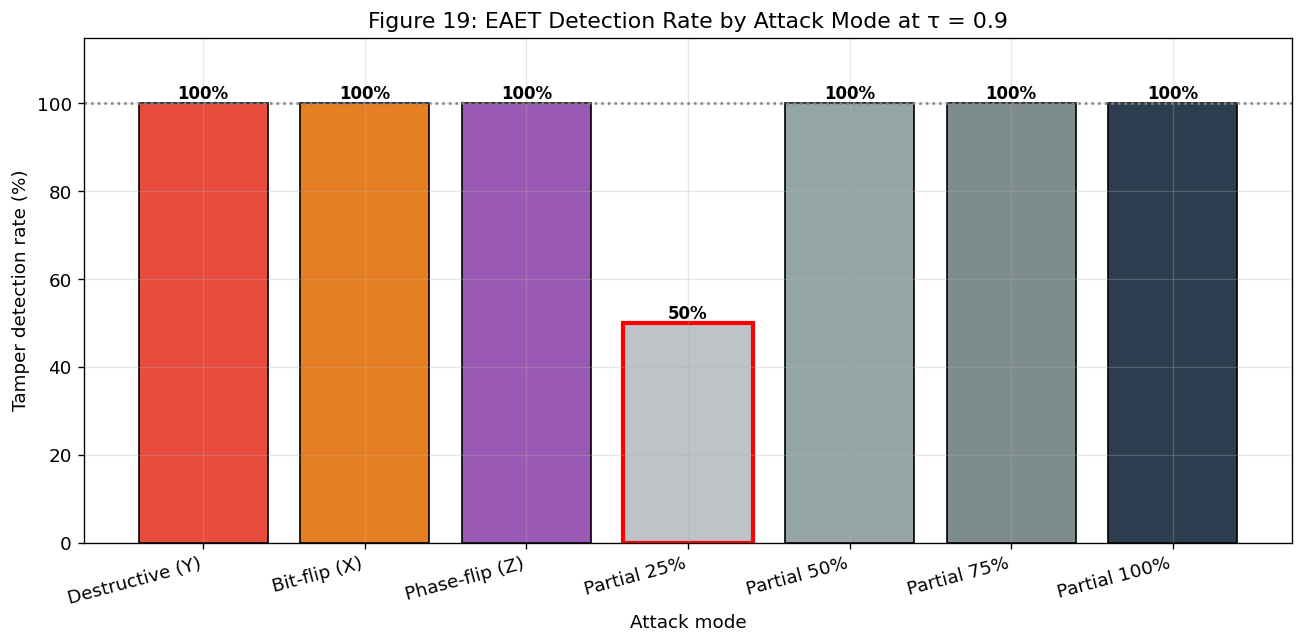

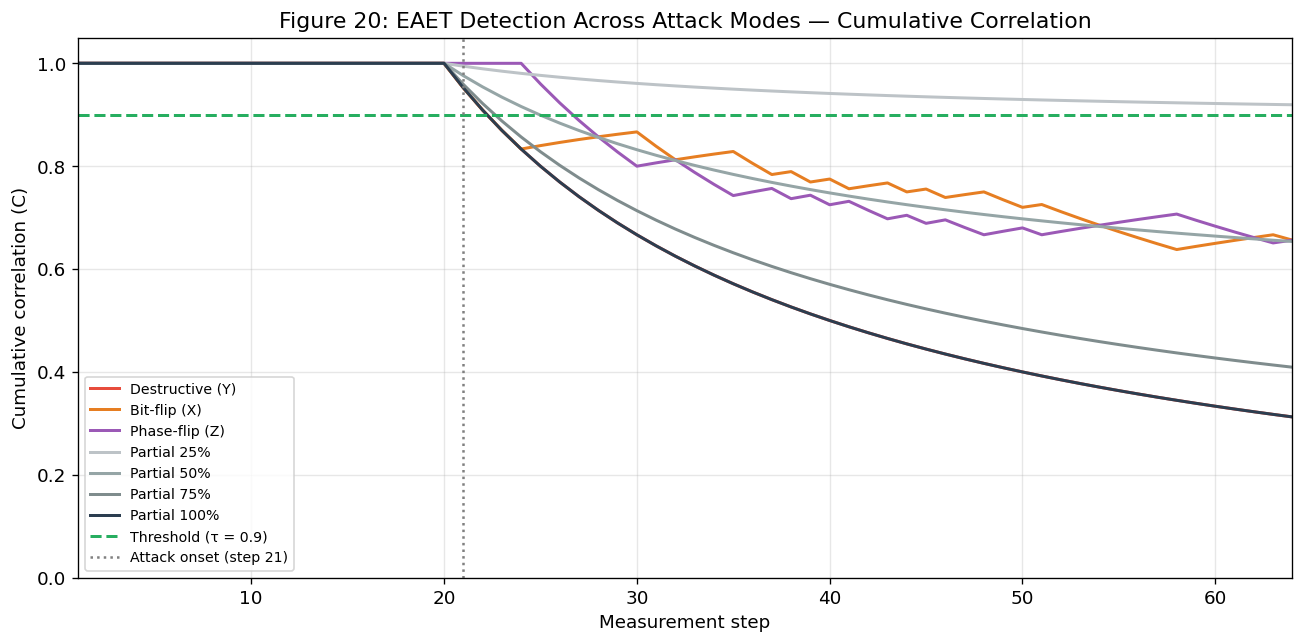

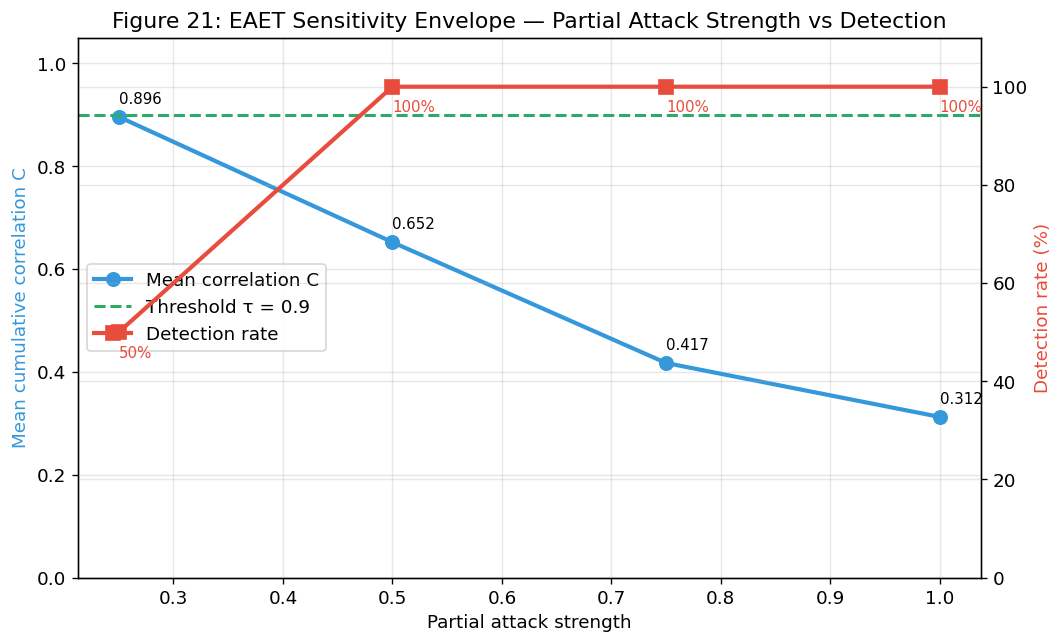

S6 figures saved.


In [39]:
labels    = [v['label']         for v in s6_results.values()]
det_rates = [v['detection_rate']*100 for v in s6_results.values()]
mean_cs   = [v['mean_final_c']  for v in s6_results.values()]
bar_colors_s6 = ['#e74c3c','#e67e22','#9b59b6',
                  '#bdc3c7','#95a5a6','#7f8c8d','#2c3e50']

# Figure 19: Detection rate bar chart
fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(labels, det_rates, color=bar_colors_s6, edgecolor='black')
ax.axhline(100, color='gray', ls=':', lw=1.5)
for bar, rate in zip(bars, det_rates):
    col = 'red' if rate < 100 else bar.get_facecolor()
    if rate < 100:
        bar.set_edgecolor('red')
        bar.set_linewidth(2.5)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.0f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Attack mode')
ax.set_ylabel('Tamper detection rate (%)')
ax.set_title(f'Figure 19: EAET Detection Rate by Attack Mode at τ = {DEFAULT_THRESHOLD}')
ax.set_ylim(0, 115)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('figures/Figure19_Attack_Mode_Detection_Rate.png', dpi=300)
plt.show()

# Figure 20: Cumulative correlation trajectories per attack mode
# Run single representative traces for the plot
fig, ax = plt.subplots(figsize=(11, 5.5))
mode_colors_plot = ['#e74c3c','#e67e22','#9b59b6',
                     '#bdc3c7','#95a5a6','#7f8c8d','#2c3e50']
for (mode_key, mode_label), col in zip(ATTACK_MODES, mode_colors_plot):
    sim = AerSimulator(seed_simulator=SEED + 7000)
    vr  = eaet_verify(H_E, recipe, tampered=True,
                       tamper_mode=mode_key, tamper_start_step=21,
                       early_stop=False, simulator=sim)
    cum = [r['cumulative_c'] for r in vr.trace]
    while len(cum) < len(recipe):
        cum.append(cum[-1])
    ax.plot(range(1, len(cum)+1), cum, label=mode_label, color=col, lw=1.8)

ax.axhline(DEFAULT_THRESHOLD, color='#27ae60', ls='--', lw=1.8,
           label=f'Threshold (τ = {DEFAULT_THRESHOLD})')
ax.axvline(21, color='gray', ls=':', lw=1.5, label='Attack onset (step 21)')
ax.set_xlabel('Measurement step')
ax.set_ylabel('Cumulative correlation (C)')
ax.set_title('Figure 20: EAET Detection Across Attack Modes — Cumulative Correlation')
ax.set_xlim(1, len(recipe)); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig('figures/Figure20_Attack_Modes_Trajectories.png', dpi=300)
plt.show()

# Figure 21: Partial attack sensitivity envelope
partial_modes  = [k for k in s6_results if k.startswith('partial')]
partial_labels = [s6_results[k]['label'] for k in partial_modes]
partial_strengths = [float(k.split('_')[1]) for k in partial_modes]
partial_cs    = [s6_results[k]['mean_final_c']    for k in partial_modes]
partial_rates = [s6_results[k]['detection_rate']*100 for k in partial_modes]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax2 = ax.twinx()
ax.plot(partial_strengths, partial_cs, 'o-', color='#3498db', lw=2.5, ms=8,
        label='Mean correlation C')
ax2.plot(partial_strengths, partial_rates, 's-', color='#e74c3c', lw=2.5, ms=8,
         label='Detection rate')
ax.axhline(DEFAULT_THRESHOLD, color='#27ae60', ls='--', lw=1.8,
           label=f'Threshold τ = {DEFAULT_THRESHOLD}')
ax.set_xlabel('Partial attack strength')
ax.set_ylabel('Mean cumulative correlation C', color='#3498db')
ax2.set_ylabel('Detection rate (%)', color='#e74c3c')
ax.set_title('Figure 21: EAET Sensitivity Envelope — Partial Attack Strength vs Detection')
for v, rate in zip(partial_strengths, partial_cs):
    ax.annotate(f'{rate:.3f}', (v, rate), textcoords='offset points', xytext=(0,8), fontsize=9)
for v, rate in zip(partial_strengths, partial_rates):
    ax2.annotate(f'{rate:.0f}%', (v, rate), textcoords='offset points', xytext=(0,-15),
                 fontsize=9, color='#e74c3c')
ax.set_ylim(0, 1.05)
ax2.set_ylim(0, 110)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='center left')
plt.tight_layout()
plt.savefig('figures/Figure21_Partial_Attack_Sensitivity.png', dpi=300)
plt.show()
print('S6 figures saved.')

## 15. Final Summary and Export

In [40]:
print('=' * 65)
print('EAET DISSERTATION — FINAL SUMMARY')
print('=' * 65)

print('\nS0  End-to-end integration:')
print(f'    Authentic ACCEPTED, C = {clean_vr.final_correlation:.4f}')
print(f'    Tampered  REJECTED, C = {tampered_vr.final_correlation:.4f}')
print(f'    Detection step        = {tampered_vr.detection_step}')
print(f'    Chain valid           = {ledger.validate(verbose=False)}')

print('\nS1  Real-time tamper detection:')
print(f'    Clean false-flag rate = {s1_results["clean_false_flags"]/TRIALS*100:.0f}%')
for onset, v in s1_results['tampered_onsets'].items():
    print(f'    Onset step {onset:>2s}: DetRate={v["detection_rate"]*100:.0f}%  '
          f'MeanDetStep={v["mean_detect_step"]:.1f}')

print('\nS2  Photon loss:')
print(f'    Tamper reject = 100% across all {len(LOSS_LEVELS)} loss levels')
print(f'    Clean accept boundary ≈ {op_limit} photon loss at τ = {DEFAULT_THRESHOLD}')

print('\nS3  Combined stress test:')
print(f'    Tamper reject rate (worst cell) = {s3_tamper_rej.min():.0f}%')
print(f'    Discriminative gap (worst cell) = {(s3_clean_c - s3_tamper_c).min():.2f}')

print('\nS4  Latency (deployment-projected):')
print(f'    Classical Blockchain : {dp["Blockchain"]["Tampered"]:.0f} ms')
print(f'    Hybrid Quantum       : {dp["Hybrid"]["Tampered"]:.0f} ms')
print(f'    EAET (tampered)      : {dp["EAET"]["Tampered"]:.0f} ms')

print(f'\nS5  ROC analysis: AUC = {auc:.4f}, Optimal τ = {opt_tau:.2f}')

print('\nS6  Multi-attack-mode:')
for mode_key, v in s6_results.items():
    print(f'    {v["label"]:18s} DetRate={v["detection_rate"]*100:.0f}%  '
          f'MeanC={v["mean_final_c"]:.3f}')

print('\nFigures generated (21 total):')
for f in sorted(os.listdir('figures')):
    print(f'  {f}')

# Final ledger export
ledger.export('results/eaet_final_audit_chain.json')

print('\nAll experiments complete. EAET dissertation prototype validated.')
print('Author: Saneru Walisadeera (w032674o)')
print('Staffordshire University — Department of Computer Science')

EAET DISSERTATION — FINAL SUMMARY

S0  End-to-end integration:
    Authentic ACCEPTED, C = 1.0000
    Tampered  REJECTED, C = 0.8696
    Detection step        = 23
    Chain valid           = True

S1  Real-time tamper detection:
    Clean false-flag rate = 0%
    Onset step 10: DetRate=100%  MeanDetStep=11.0
    Onset step 21: DetRate=100%  MeanDetStep=23.0
    Onset step 32: DetRate=100%  MeanDetStep=35.0
    Onset step 45: DetRate=100%  MeanDetStep=49.0

S2  Photon loss:
    Tamper reject = 100% across all 11 loss levels
    Clean accept boundary ≈ None photon loss at τ = 0.9

S3  Combined stress test:
    Tamper reject rate (worst cell) = 100%
    Discriminative gap (worst cell) = 0.31

S4  Latency (deployment-projected):
    Classical Blockchain : 300 ms
    Hybrid Quantum       : 128 ms
    EAET (tampered)      : 46 ms

S5  ROC analysis: AUC = 1.0000, Optimal τ = 0.40

S6  Multi-attack-mode:
    Destructive (Y)    DetRate=100%  MeanC=0.312
    Bit-flip (X)       DetRate=100%  Mea